<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

In [1]:
!gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO # sound_classification_dataset.zip
!gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT # train.csv
!gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 # valid.csv
!gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks # test.csv

Downloading...
From (original): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO
From (redirected): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO&confirm=t&uuid=473b1f87-2b4c-4462-b0ec-ca2637ea0475
To: /content/sound_classification_dataset.zip
100% 645M/645M [00:23<00:00, 27.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT
To: /content/train.csv
100% 3.09k/3.09k [00:00<00:00, 13.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1my0RPDQdTxvCGmnZei06tiXgKko3R4o4
To: /content/valid.csv
100% 1.06k/1.06k [00:00<00:00, 5.72MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks
To: /content/test.csv
100% 719/719 [00:00<00:00, 3.24MB/s]


Разархивируйте zip файл, где содержатся wav файлы датасета.

In [2]:
!unzip /content/sound_classification_dataset.zip

Archive:  /content/sound_classification_dataset.zip
   creating: content/sound_classification_dataset/
  inflating: content/sound_classification_dataset/1-61261-A-44.wav  
  inflating: content/sound_classification_dataset/2-104105-A-19.wav  
  inflating: content/sound_classification_dataset/3-150363-A-38.wav  
  inflating: content/sound_classification_dataset/1-18074-A-6.wav  
  inflating: content/sound_classification_dataset/5-161270-A-33.wav  
  inflating: content/sound_classification_dataset/5-221529-A-39.wav  
  inflating: content/sound_classification_dataset/2-61618-A-46.wav  
  inflating: content/sound_classification_dataset/1-46274-A-18.wav  
  inflating: content/sound_classification_dataset/1-69760-A-16.wav  
  inflating: content/sound_classification_dataset/2-64963-A-15.wav  
  inflating: content/sound_classification_dataset/2-108766-A-9.wav  
  inflating: content/sound_classification_dataset/4-165845-A-45.wav  
  inflating: content/sound_classification_dataset/5-235644-A-30.w

In [3]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

In [4]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

In [5]:
!pip install -q torch-audiomentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.5 MB/s eta 0:00:00


In [6]:
import torch
import torchaudio
import torchaudio.functional as F
from torch.utils.data import Dataset
import pandas as pd
import os
from torch_audiomentations import Compose, Gain, PolarityInversion, PitchShift

class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    def __init__(self, data_frame, label_encoder=None, is_test=False, audio_length=5, do_augmentation=False):
        self.data_frame = data_frame
        self.label_encoder = label_encoder
        self.audio_length = audio_length
        self.do_augmentation = do_augmentation
        self.is_test = is_test

    def __len__(self):
        return self.data_frame.shape[0]

    def __getitem__(self, index):
        audio_file_path = f'/content/content/sound_classification_dataset/{self.data_frame.iloc[index, 0]}'
        if not self.is_test:
            label = self.label_encoder.transform([self.data_frame.iloc[index, 1]]).item()

        # 2. LOAD: Load the raw audio file
        signal, sample_rate = torchaudio.load(audio_file_path)

        # 3. PREPROCESS: Apply the preprocessing steps
        signal = self._resample(signal, sample_rate) # Resample to the sample rate 16000
        signal = self._stereo_to_mono(signal) # Converts (channels, samples) -> (samples,)
        signal = self._cut_or_pad(signal) # State fixed length

        # 4. AUGMENT: Apply augmentations only if training
        if self.do_augmentation:
            signal = self._augmentation(signal)

        signal = signal.squeeze(1)

        # 5. RETURN: We now have a clean, standardized waveform and its label
        if self.is_test:
            return signal

        return signal, label

    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr):
        signal = F.resample(signal, original_sr, 16000)
        return signal

    def _stereo_to_mono(self, signal):
        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True)

        return signal

    def _cut_or_pad(self, signal):
        if len(signal[0]) / 16000 < self.audio_length:
            signal = torch.nn.functional.pad(signal, (0, 16000 * self.audio_length - len(signal[0])), "constant", 0.0)
        else:
            signal = signal[:, :(16000 * self.audio_length)]

        return signal

    def _augmentation(self, signal):
        apply_augmentation = Compose(
            transforms=[
                Gain(sample_rate=16000),
                PolarityInversion(sample_rate=16000),
                PitchShift(sample_rate=16000)
            ]
        )
        signal = apply_augmentation(signal.reshape((1, 1, 16000 * self.audio_length)), sample_rate=16000)[0]

        return signal

In [7]:
label_encoder = LabelEncoder()

label_encoder.fit(train_df.category.unique())

LabelEncoder()

In [8]:
train_dataset = SimpleAudioDataset(train_df, label_encoder, do_augmentation=True)
valid_dataset = SimpleAudioDataset(valid_df, label_encoder)

### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

In [9]:
from torch import nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super().__init__()
        self.conv = nn.Conv1d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=kernel_size, stride=stride)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)

        return x

In [24]:
class SoundClassificationModel(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes, strides, paddings, num_classes=5):
        super().__init__()

        if not(len(in_channels) == len(out_channels) == len(kernel_sizes) == len(strides) == len(paddings)):
            raise ValueError('Размеры параметров не совпадают')
        for i in range(len(out_channels) - 1):
            if in_channels[i + 1] != out_channels[i]:
                raise ValueError('Ошибка в матчинге каналов')

        self.feautre_extractor = nn.Sequential()

        for i in range(len(in_channels)):
            self.feautre_extractor.add_module(f'ConvBlock{i + 1}', ConvBlock(
                in_channels[i], out_channels[i], kernel_sizes[i], strides[i], paddings[i]
            ))

        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.maxpool = nn.AdaptiveMaxPool1d(1)


        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(out_channels[-1] * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.feautre_extractor(x)
        x_avgpool = self.avgpool(x)
        x_maxpool = self.maxpool(x)
        x = self.classifier(torch.cat([x_avgpool, x_maxpool], dim=1))

        return x

### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [11]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


epoch 1


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

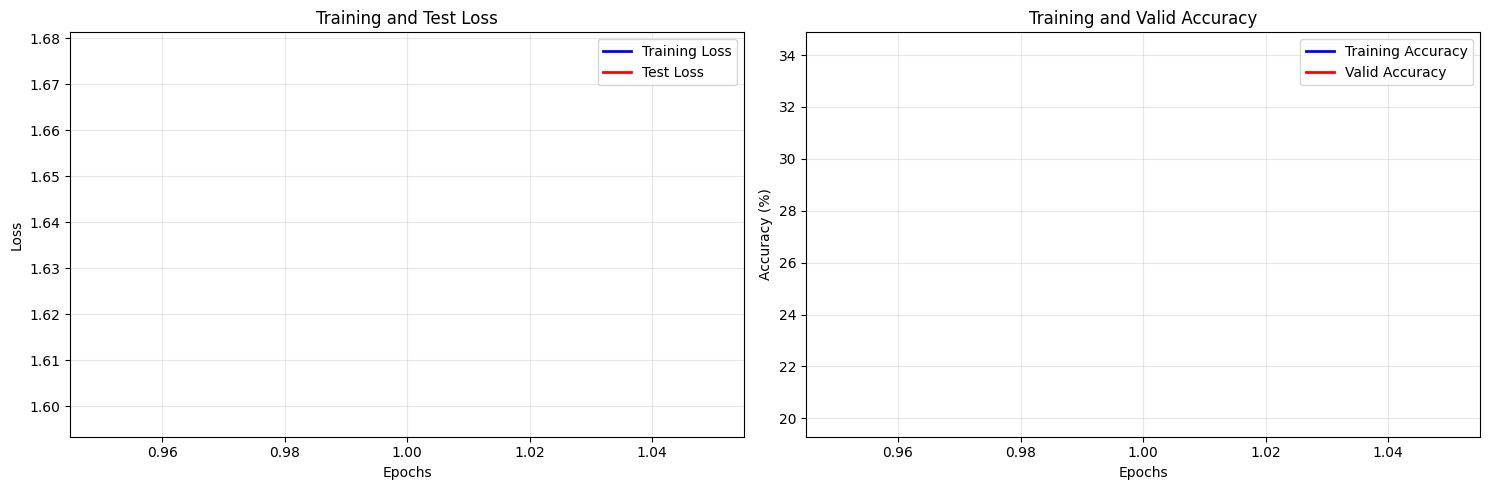

epoch 2


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

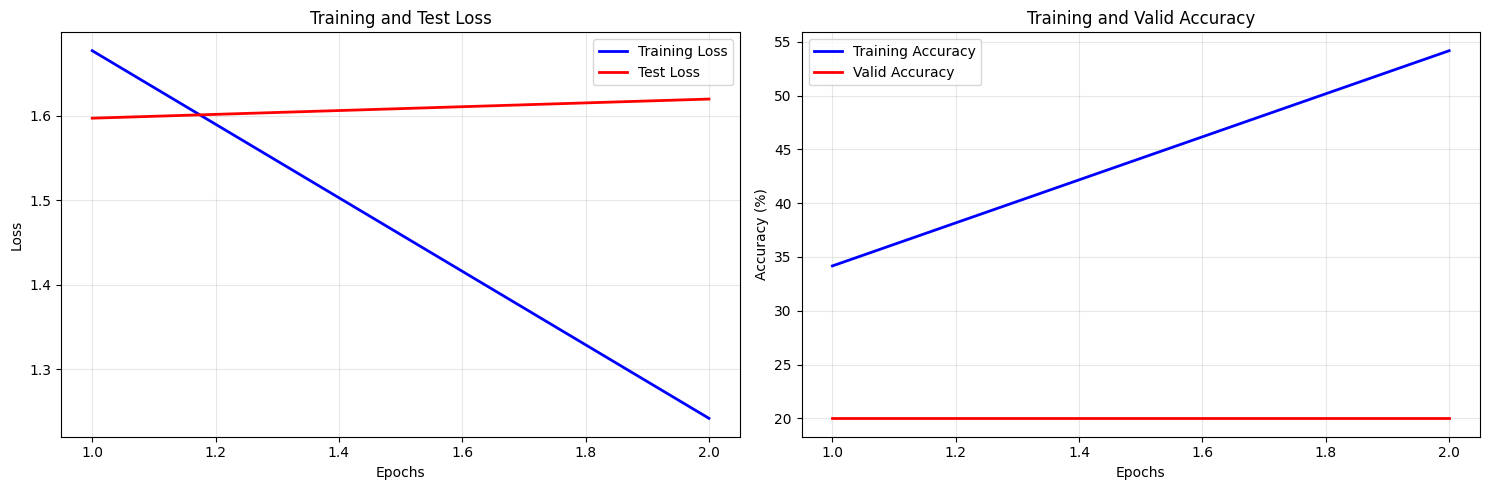

epoch 3


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

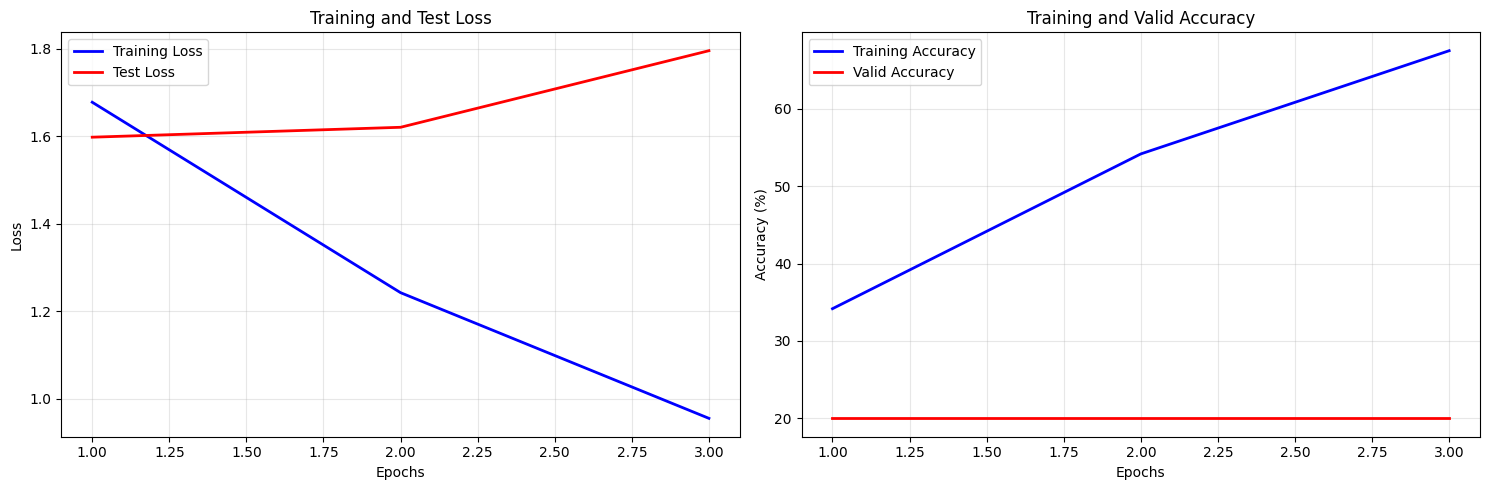

epoch 4


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

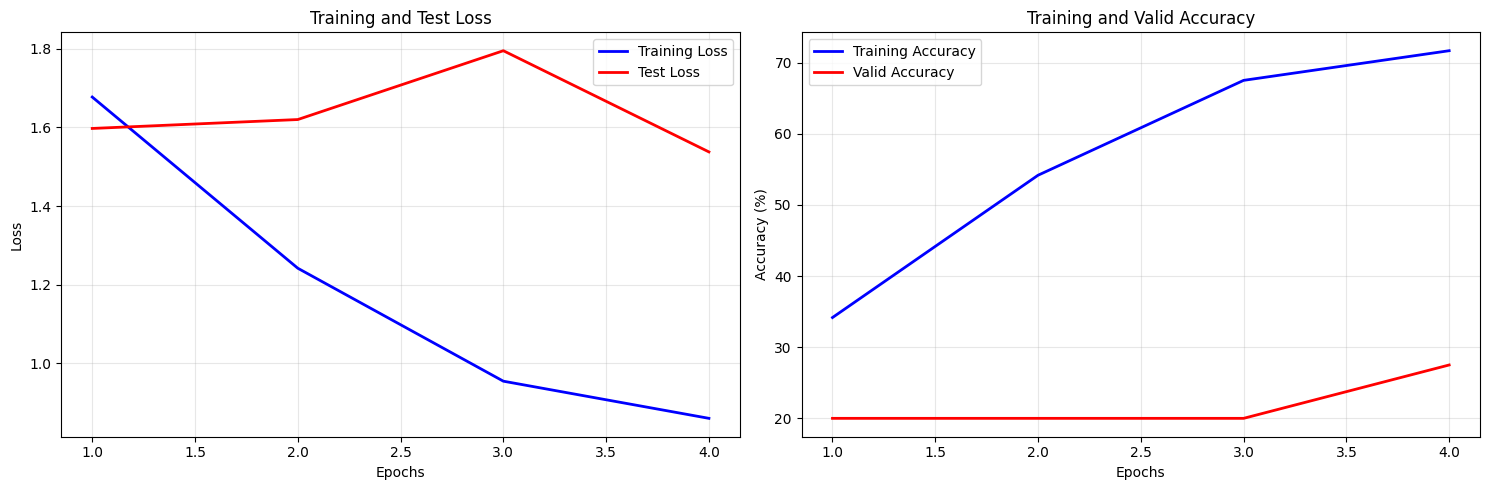

epoch 5


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

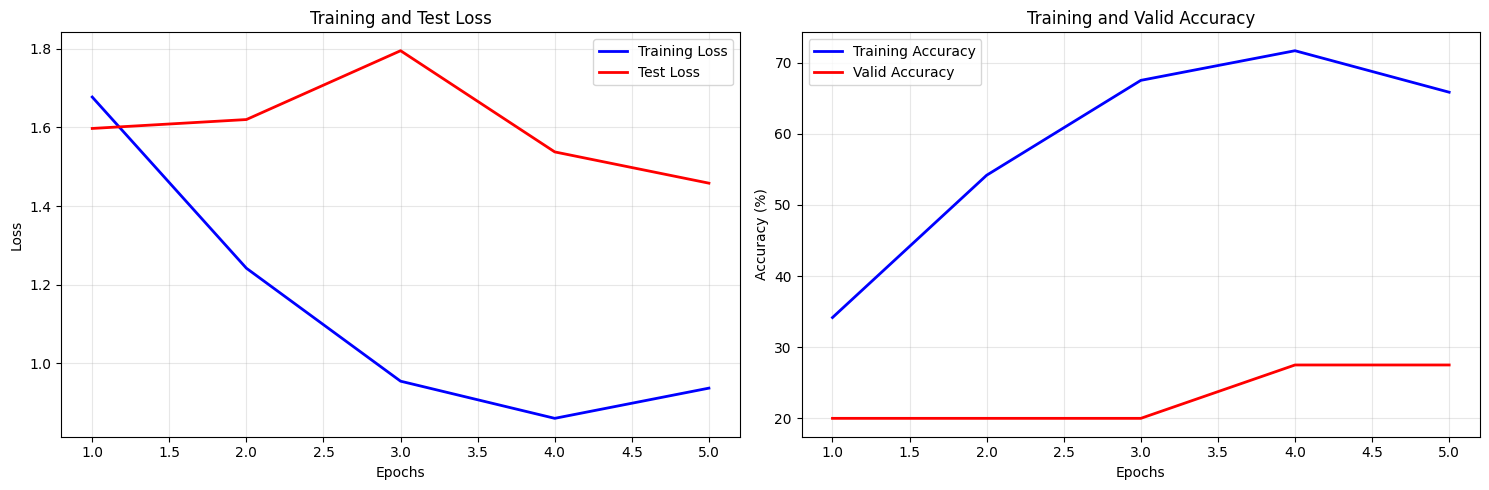

epoch 6


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

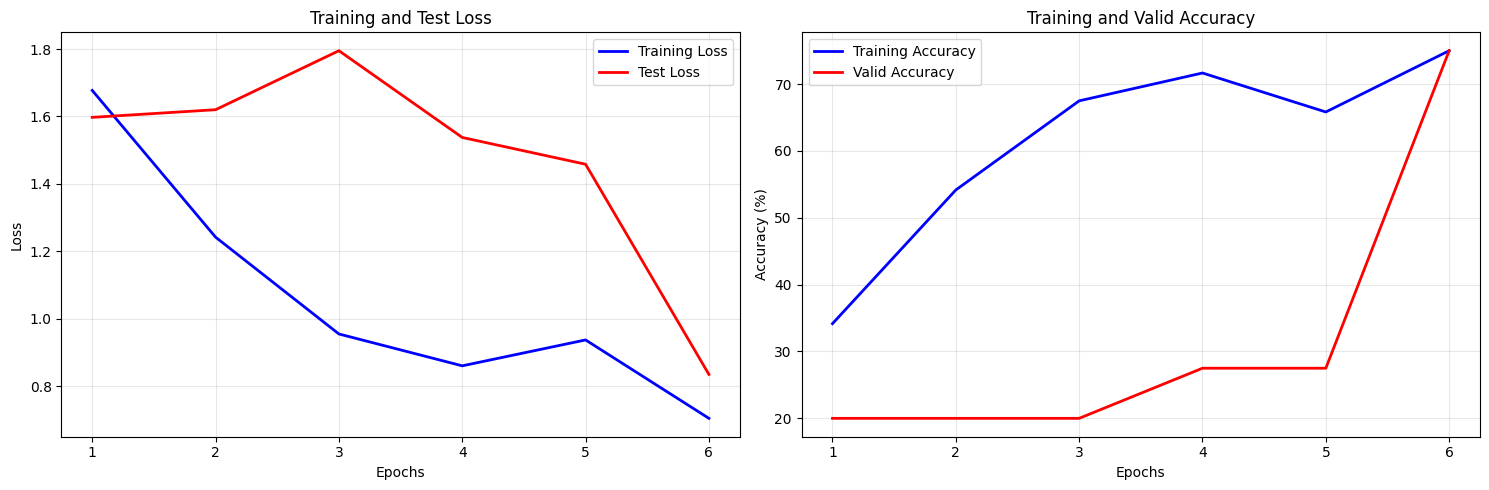

epoch 7


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

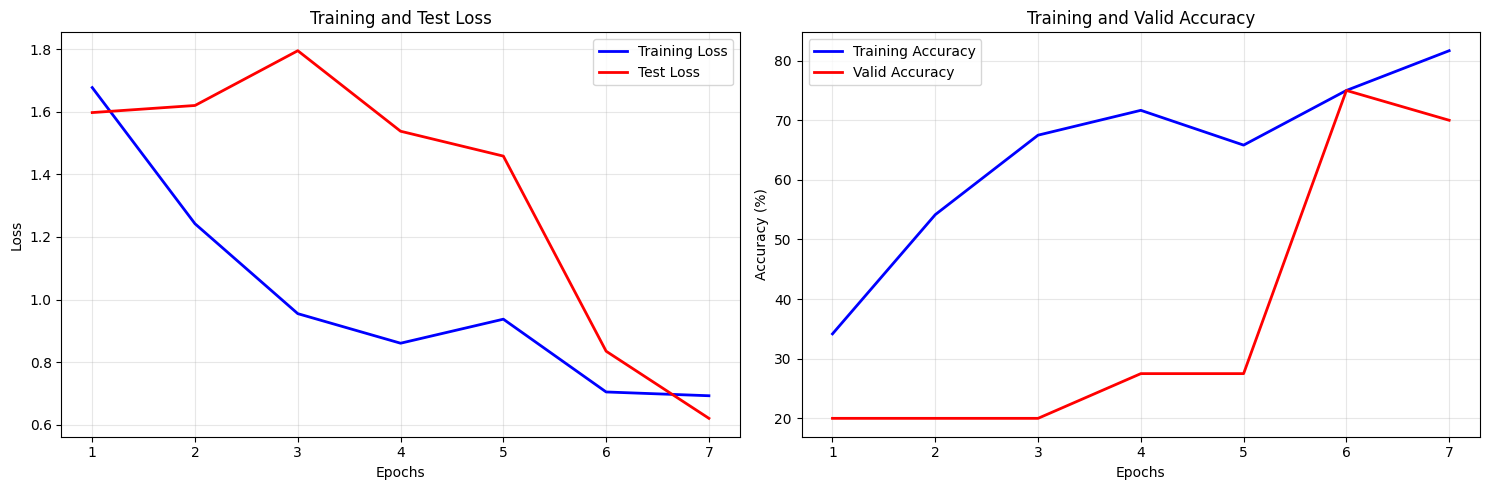

epoch 8


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

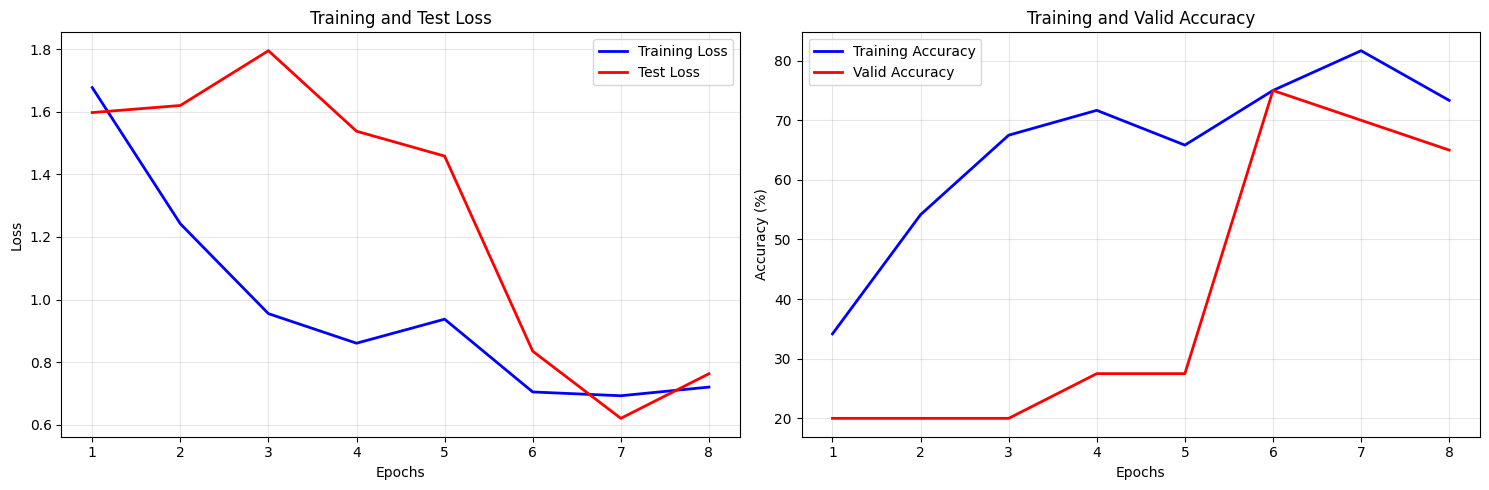

epoch 9


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

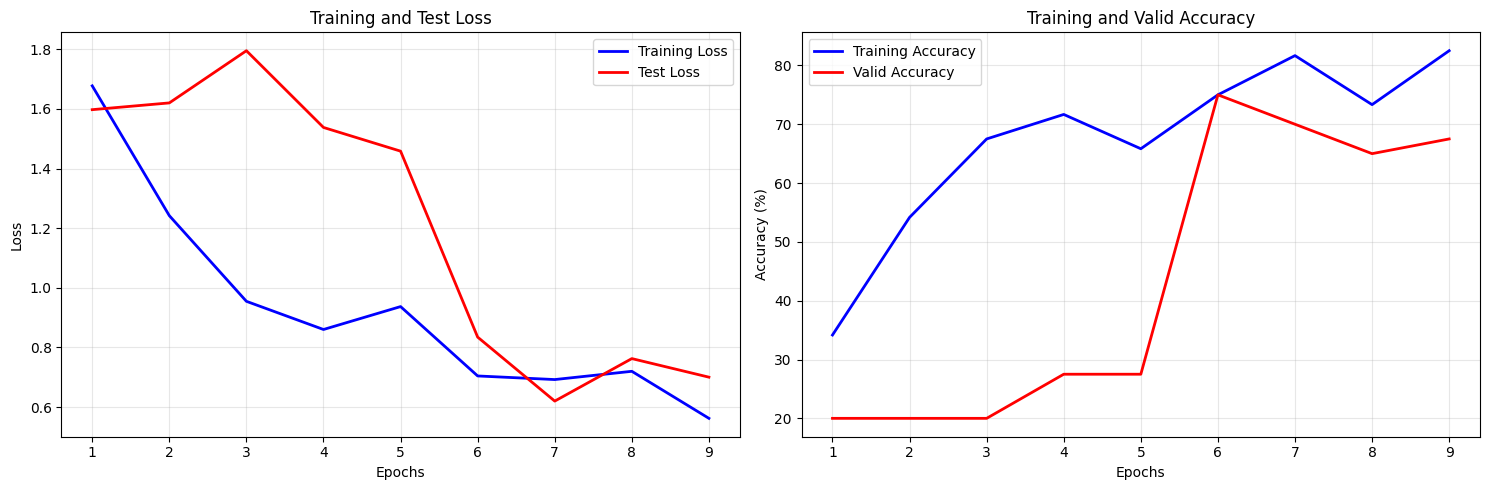

epoch 10


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

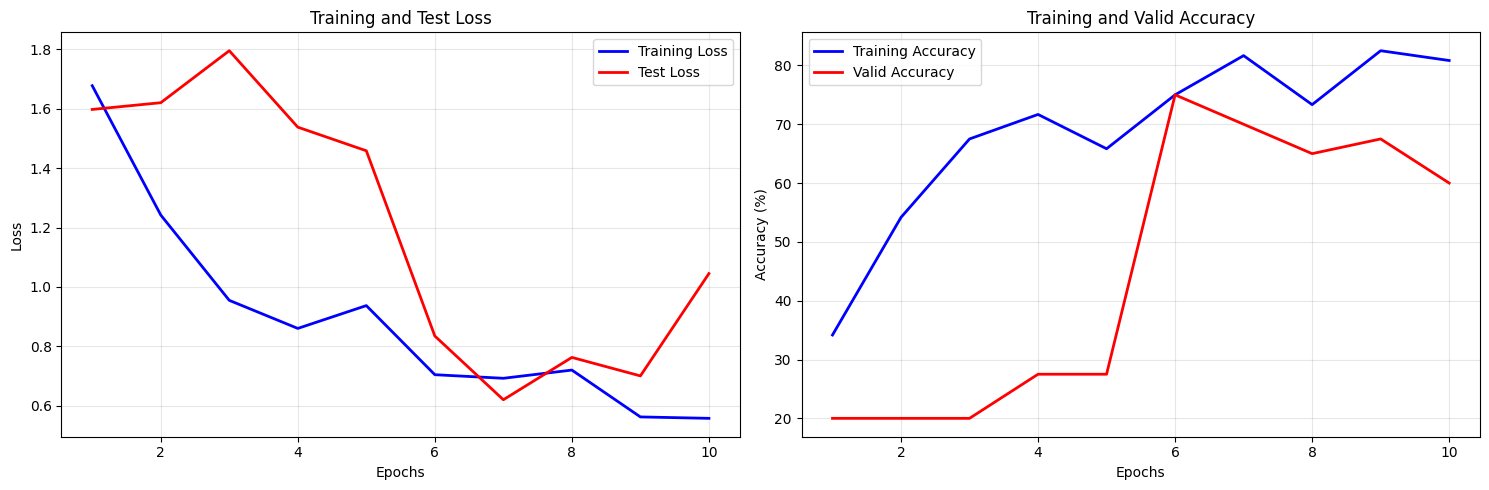

epoch 11


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

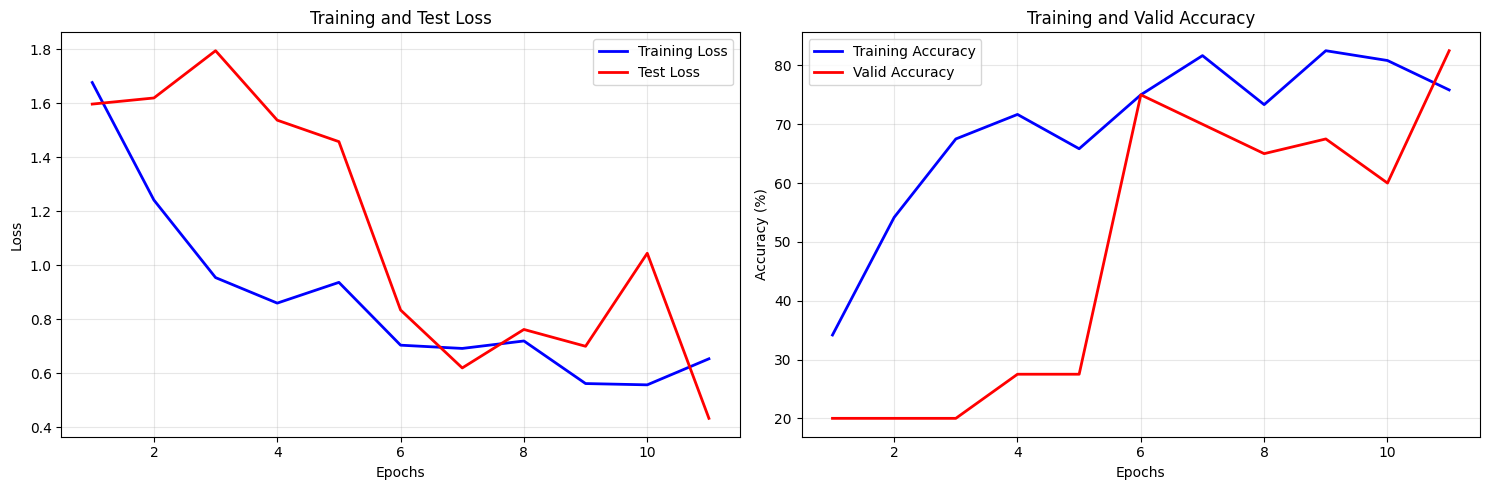

epoch 12


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

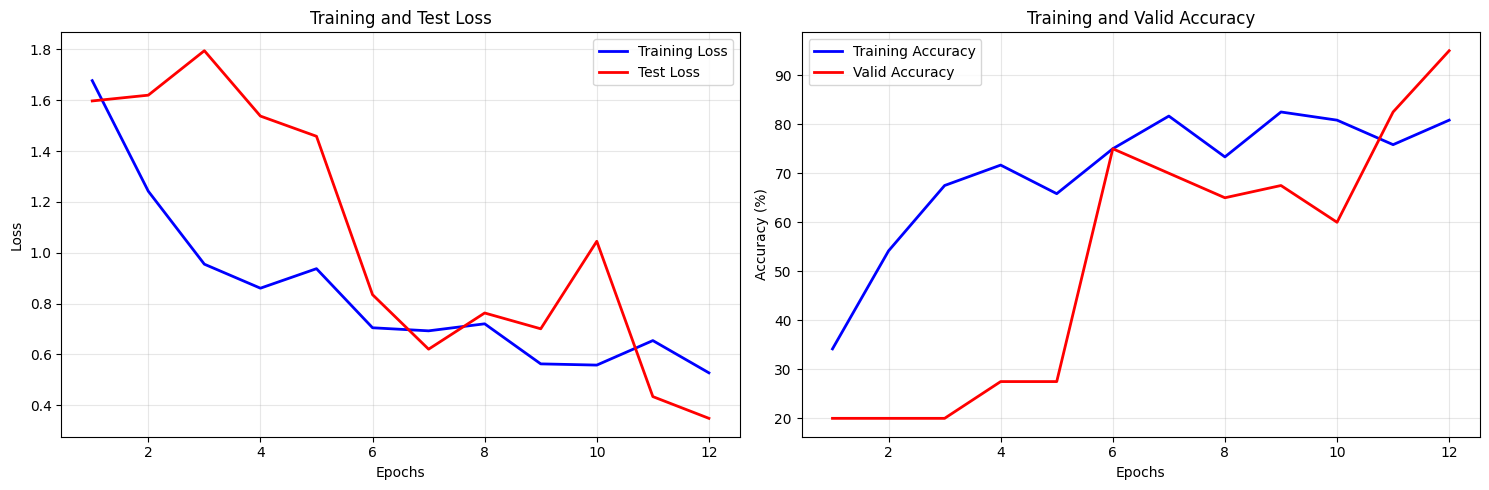

epoch 13


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

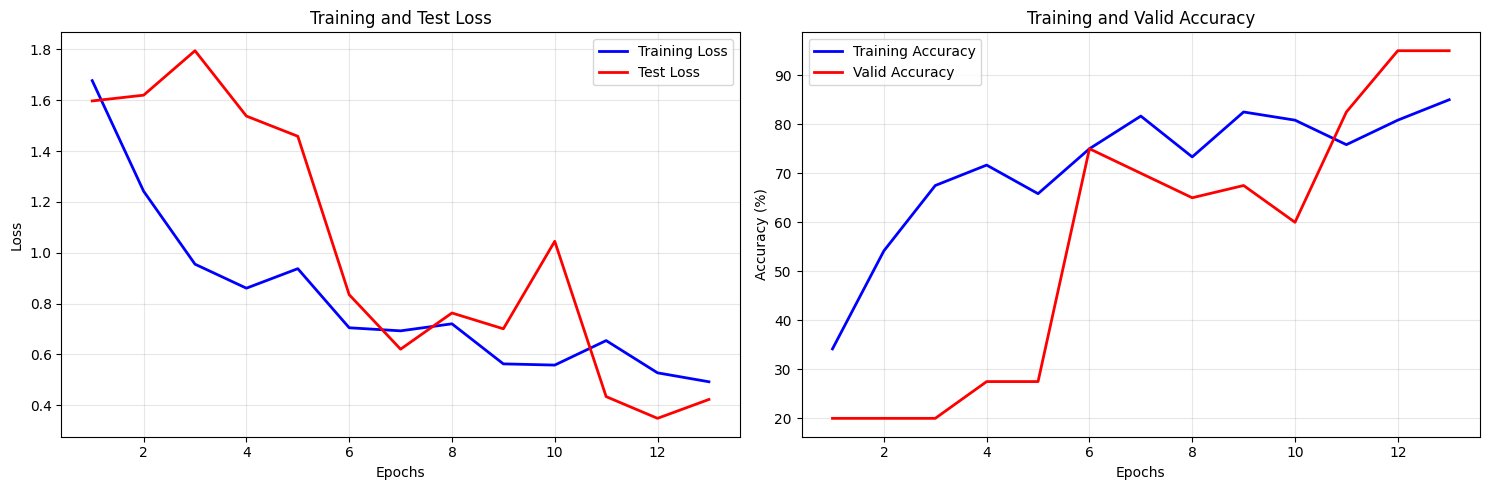

epoch 14


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

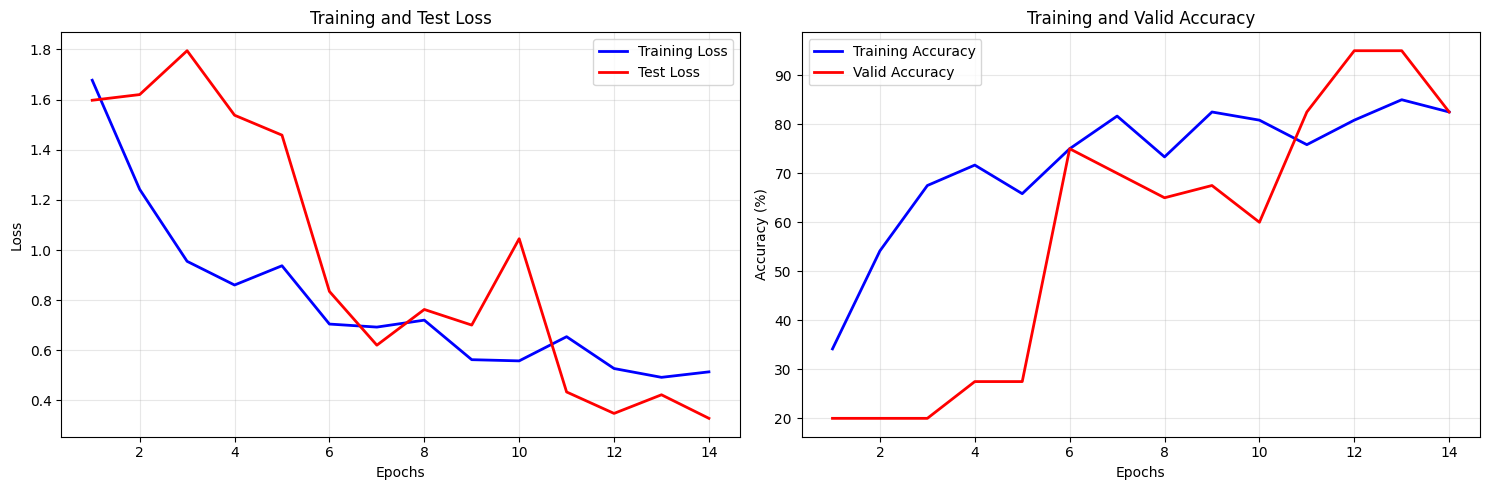

epoch 15


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

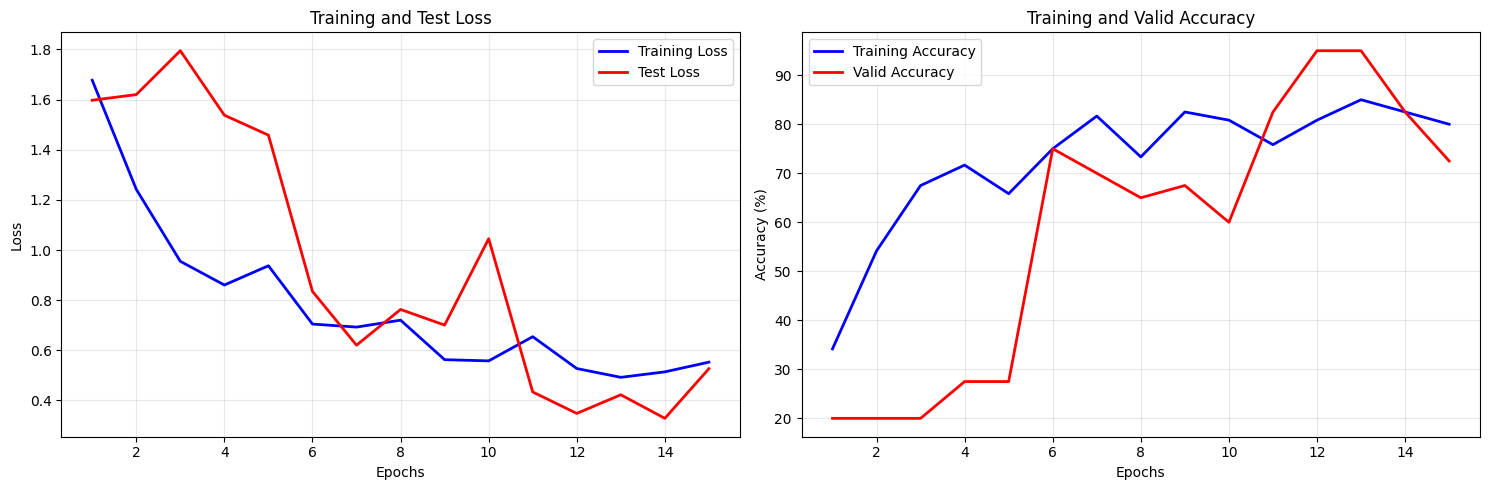

epoch 16


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

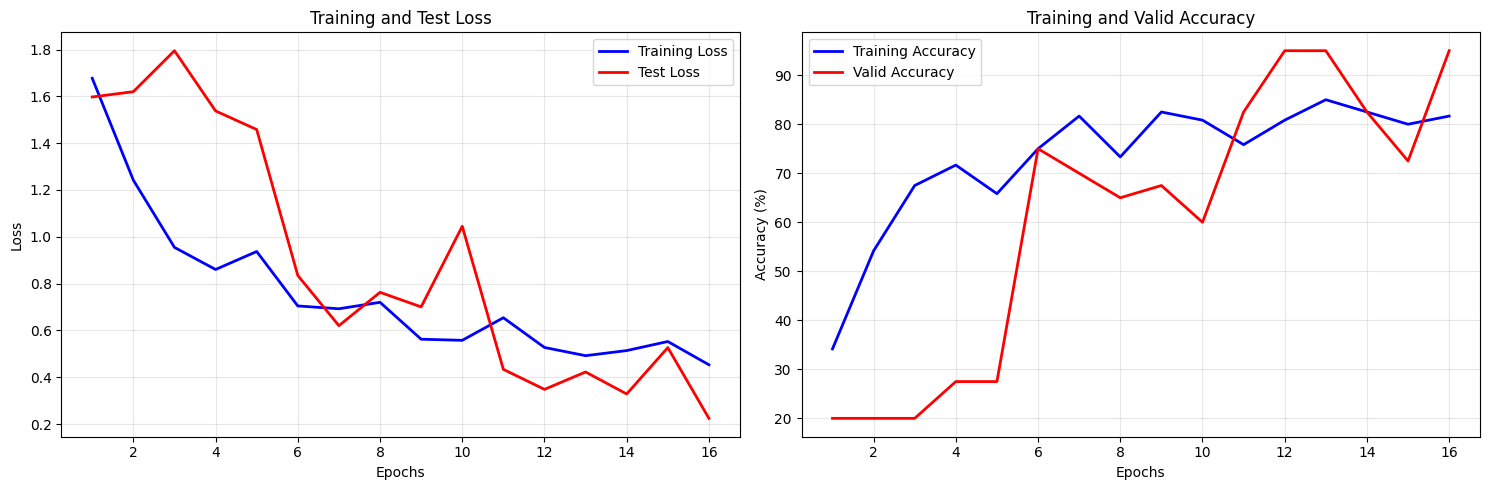

epoch 17


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

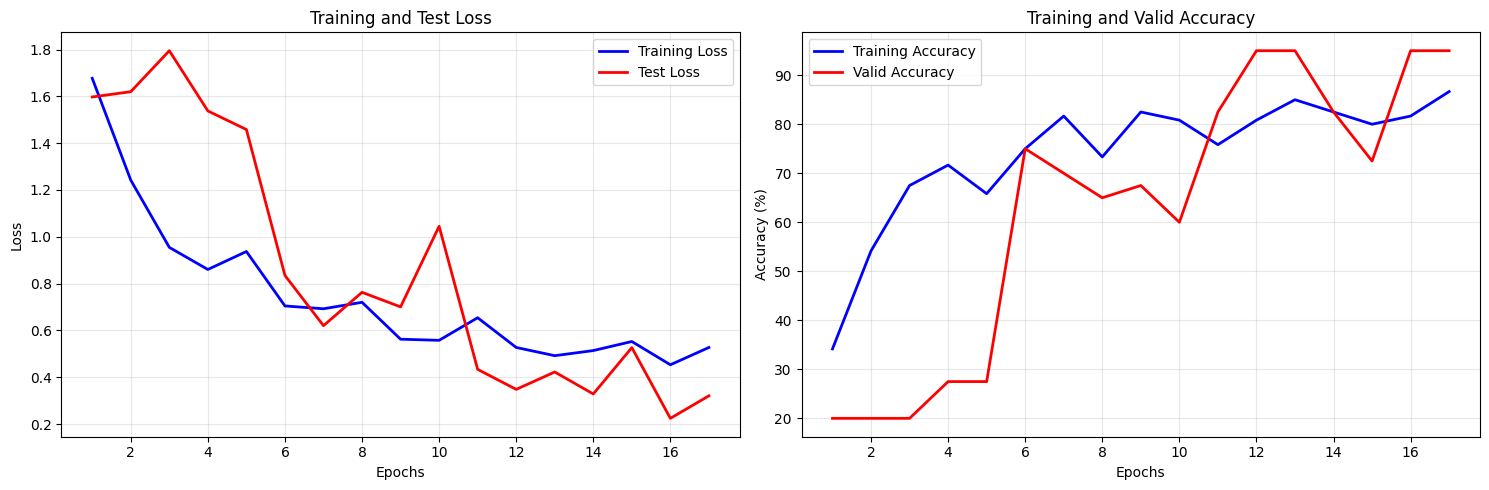

epoch 18


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

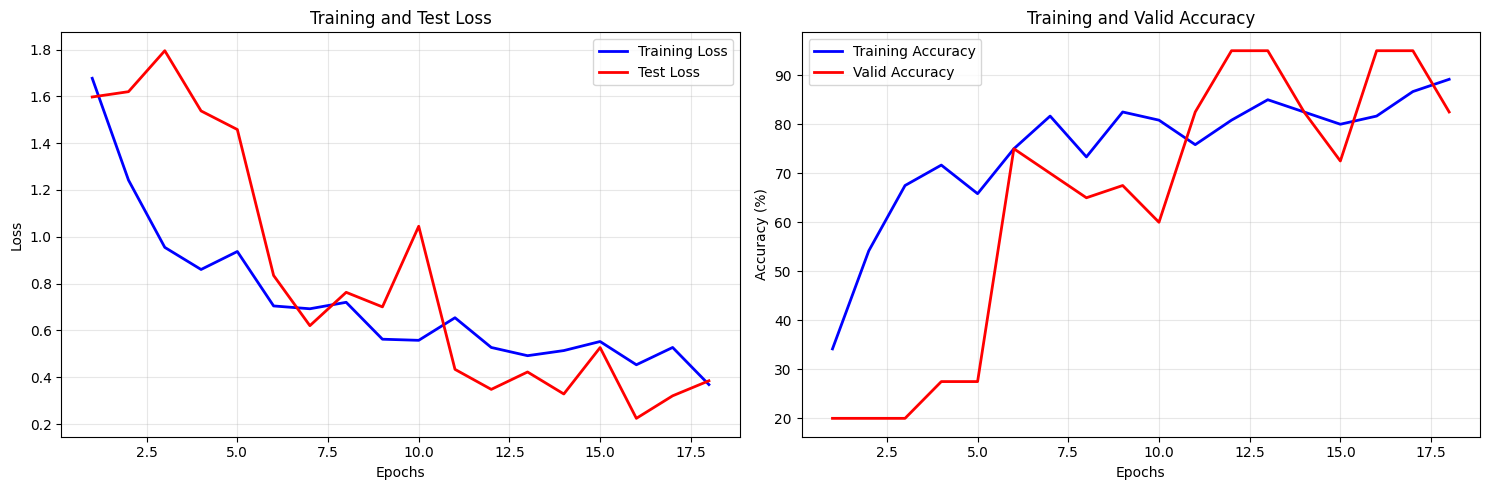

epoch 19


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

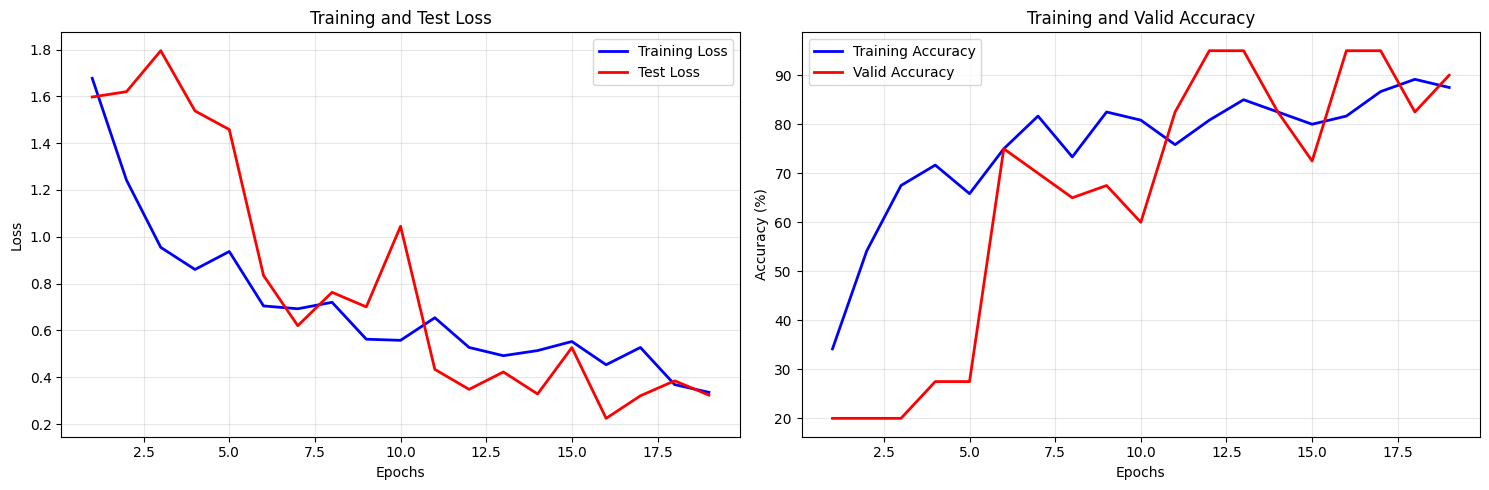

epoch 20


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

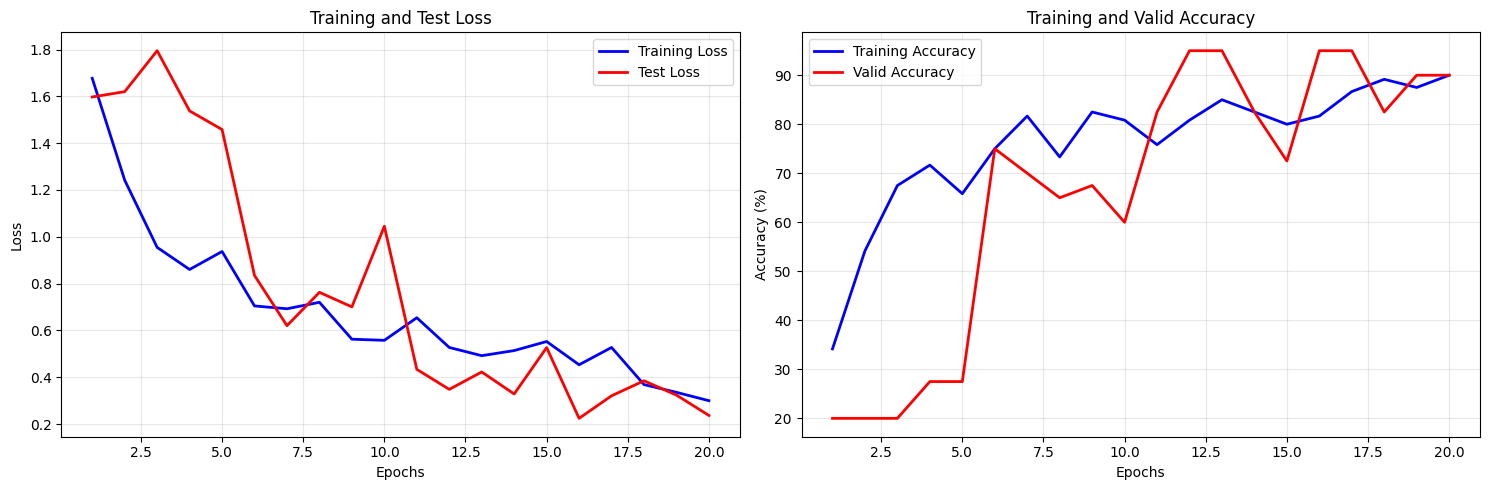

epoch 21


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

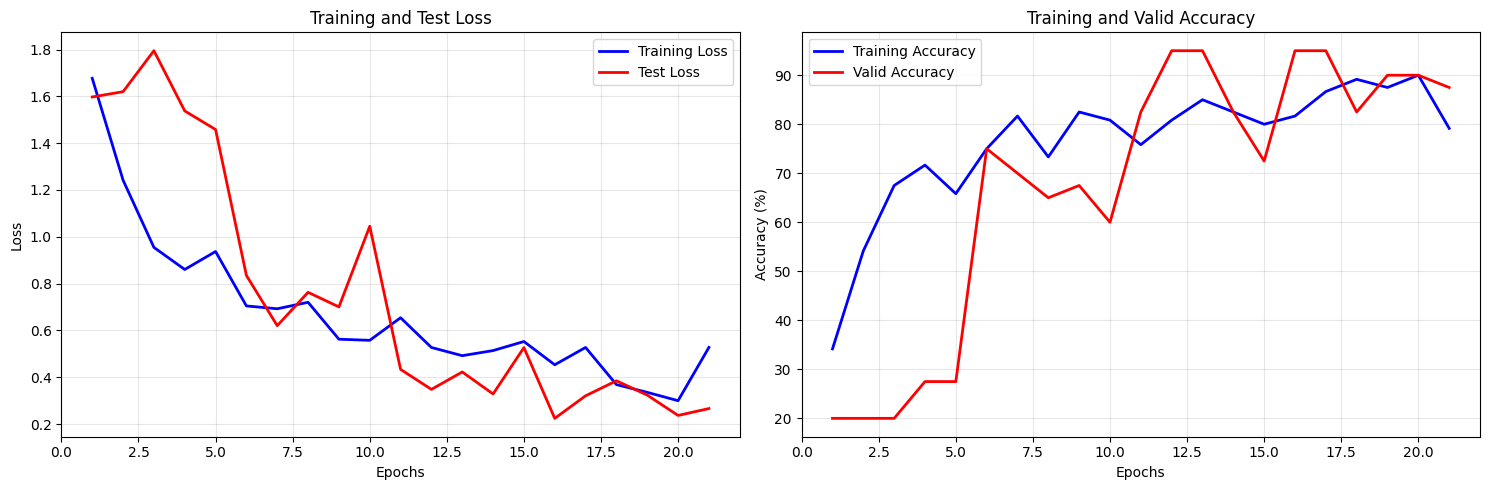

epoch 22


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

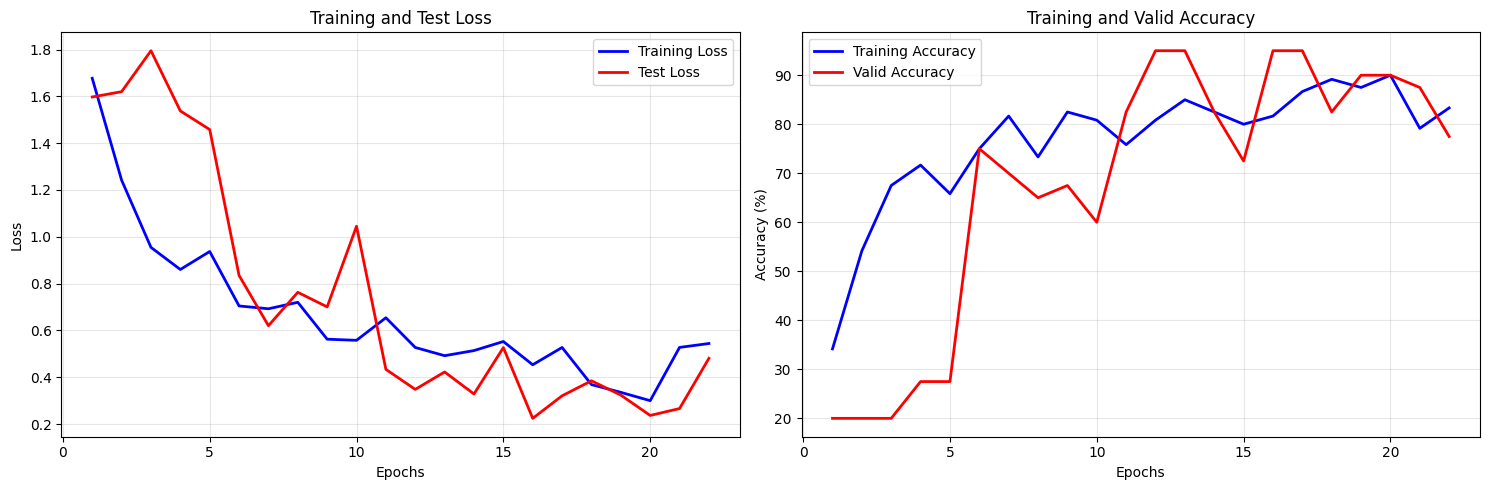

epoch 23


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

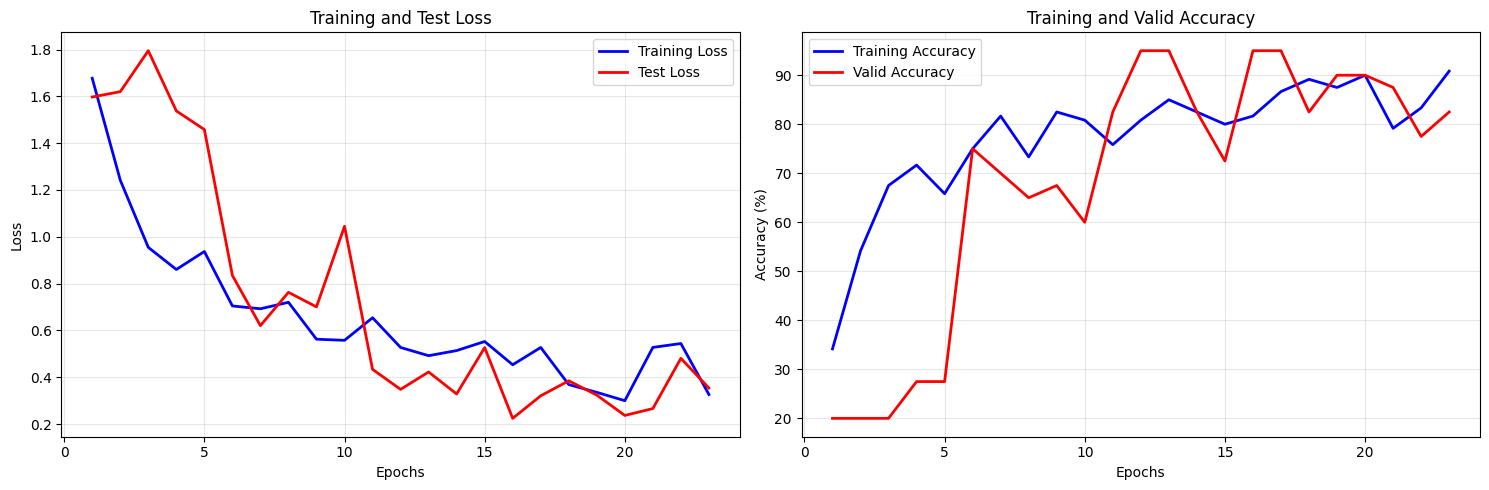

epoch 24


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

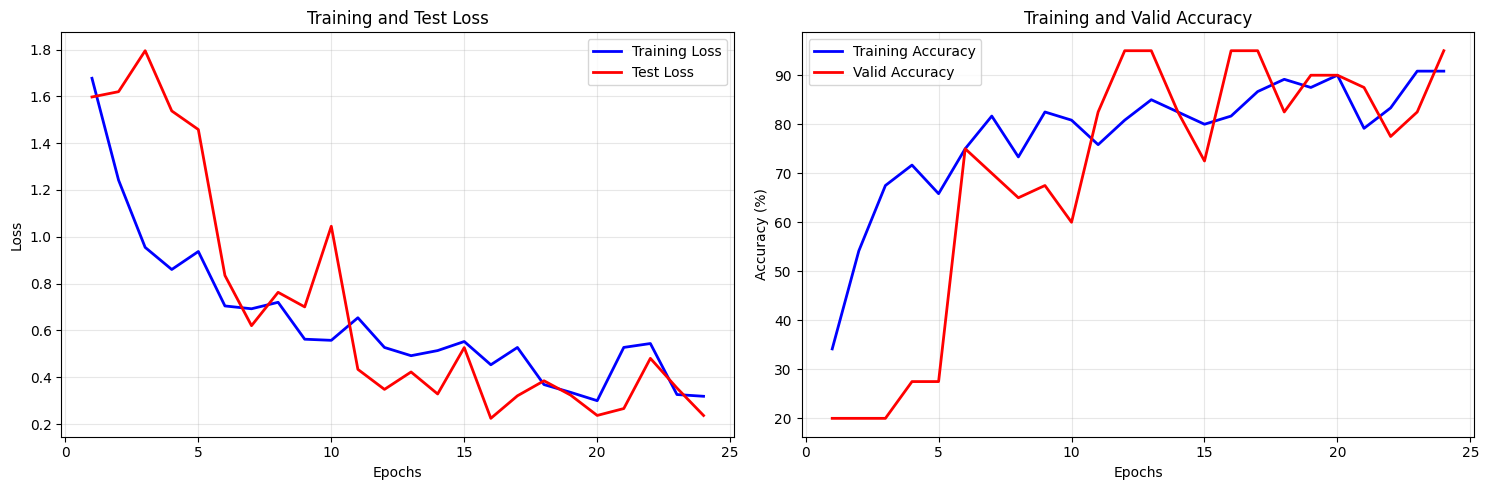

epoch 25


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

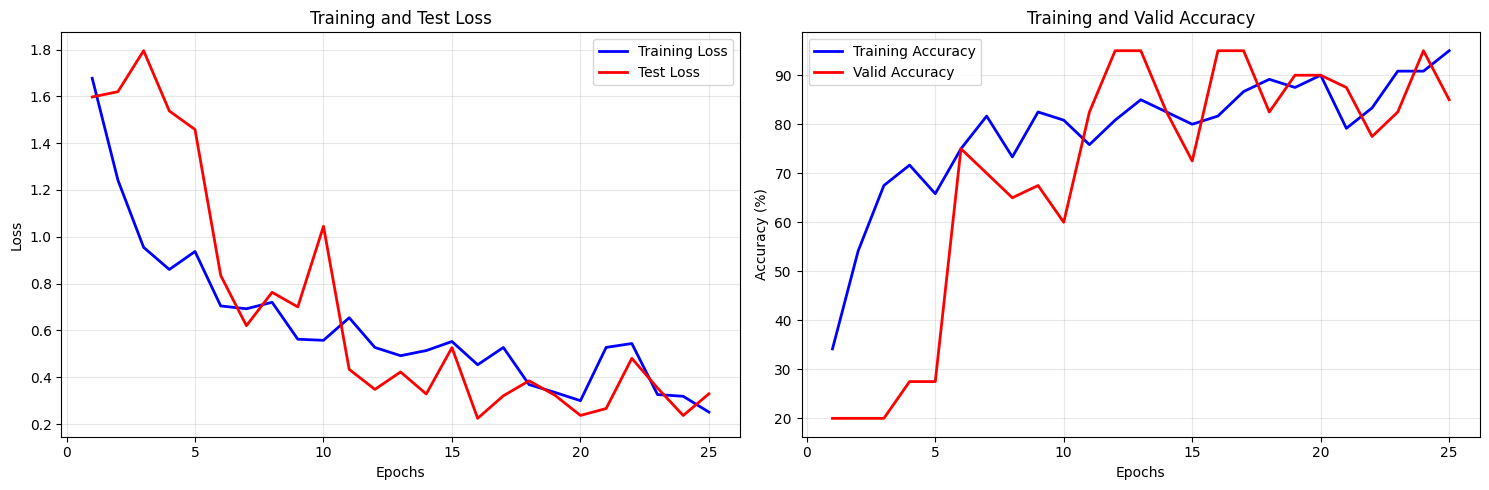

epoch 26


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

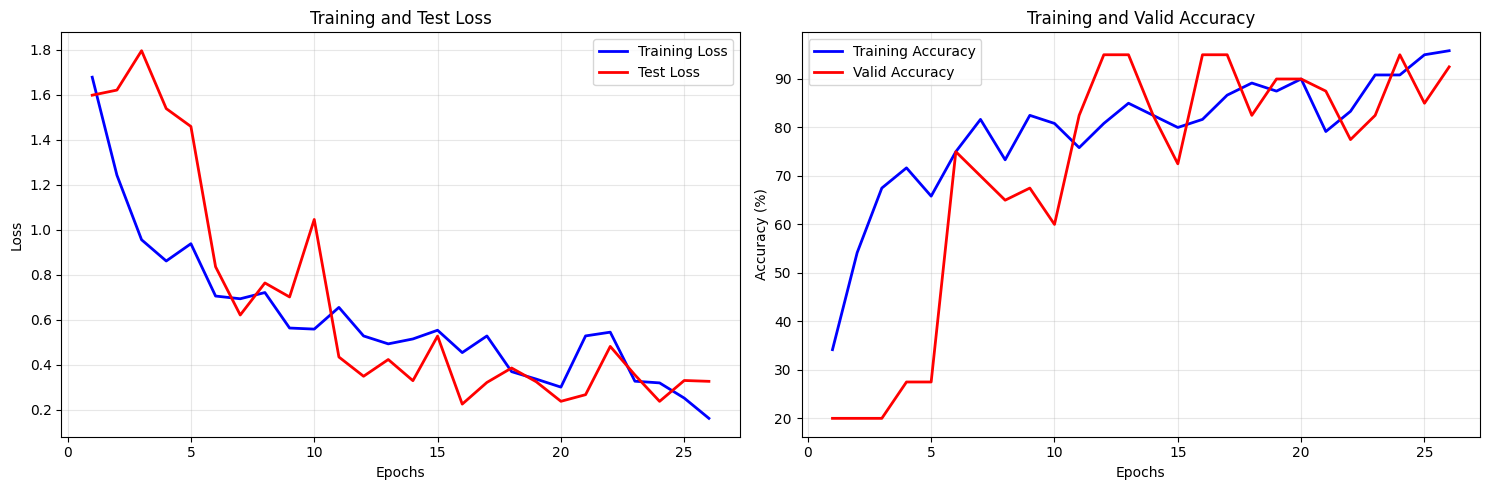

epoch 27


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

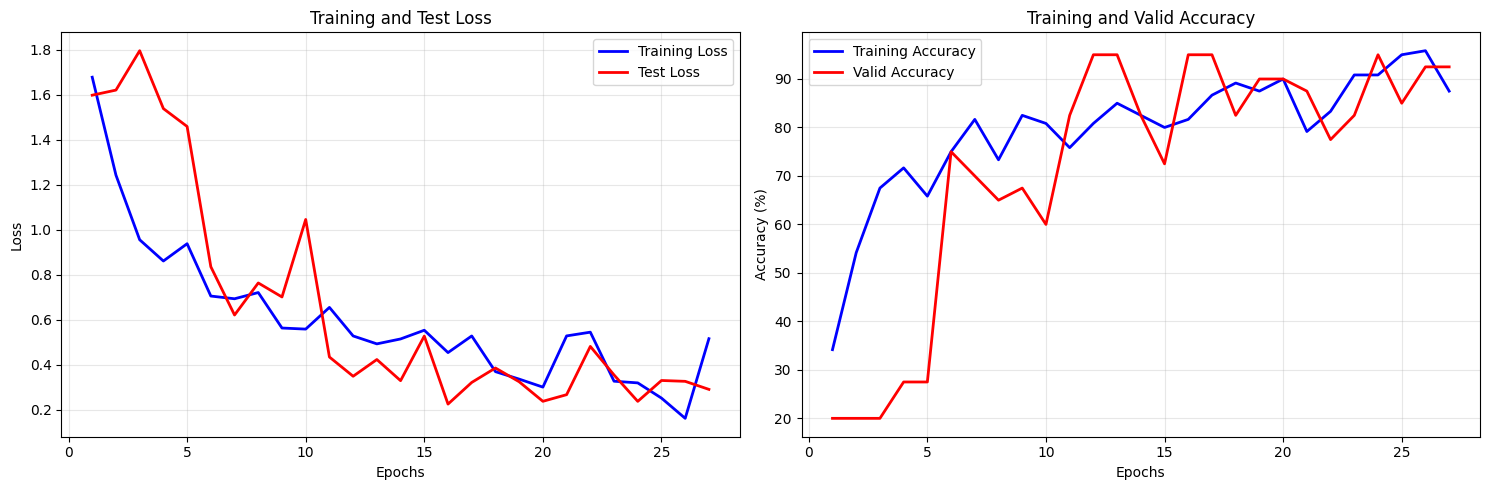

epoch 28


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

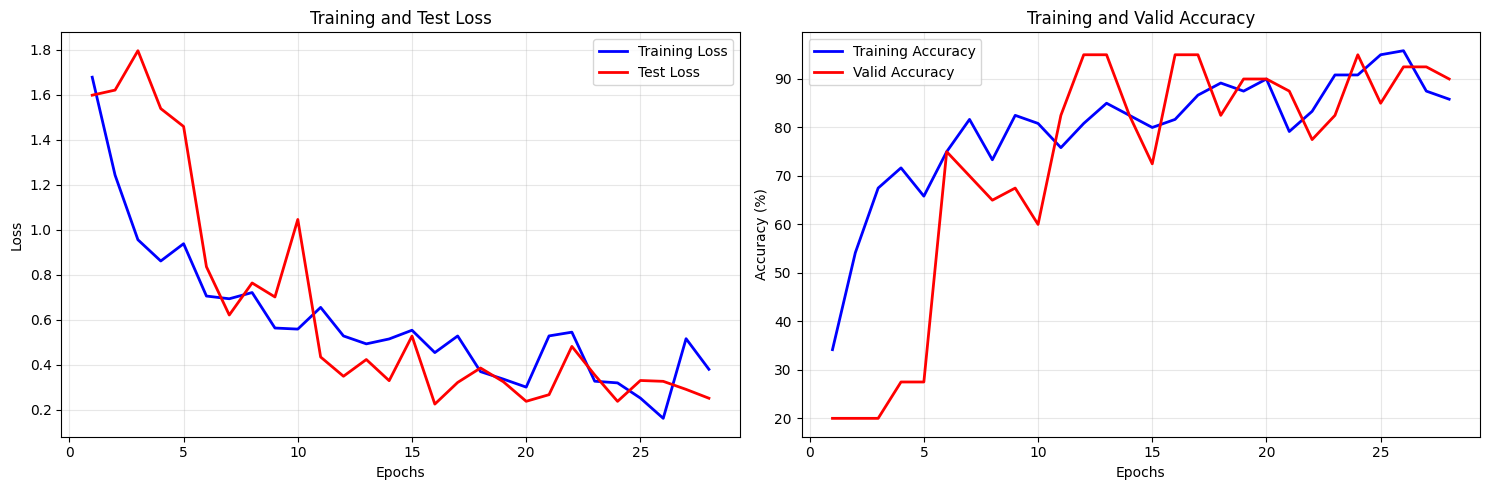

epoch 29


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

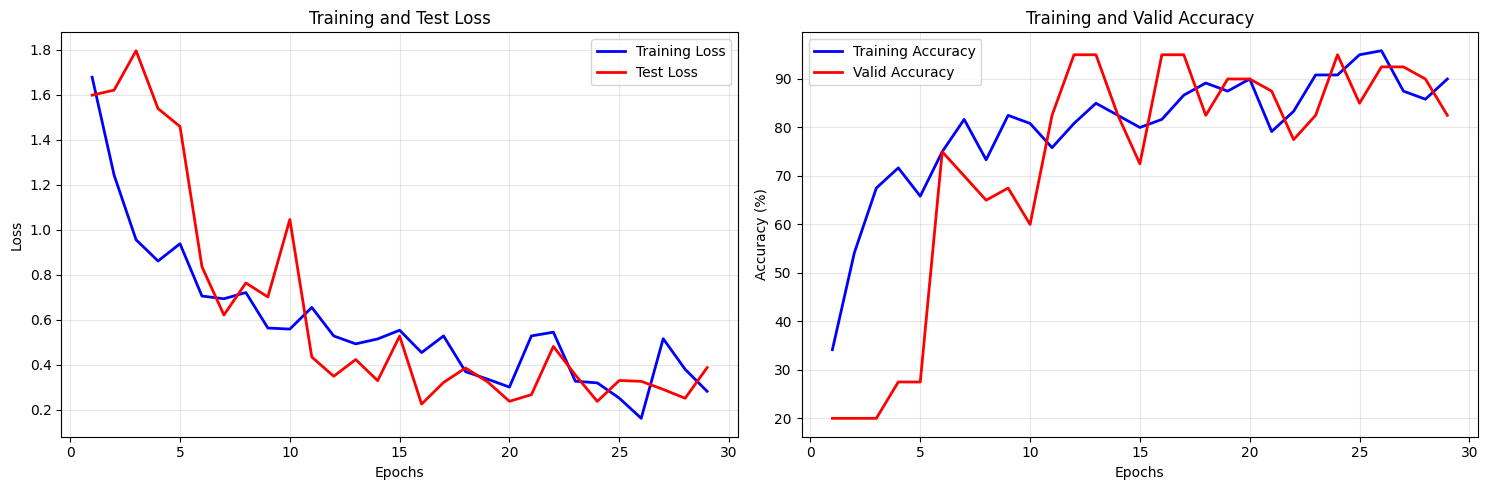

epoch 30


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

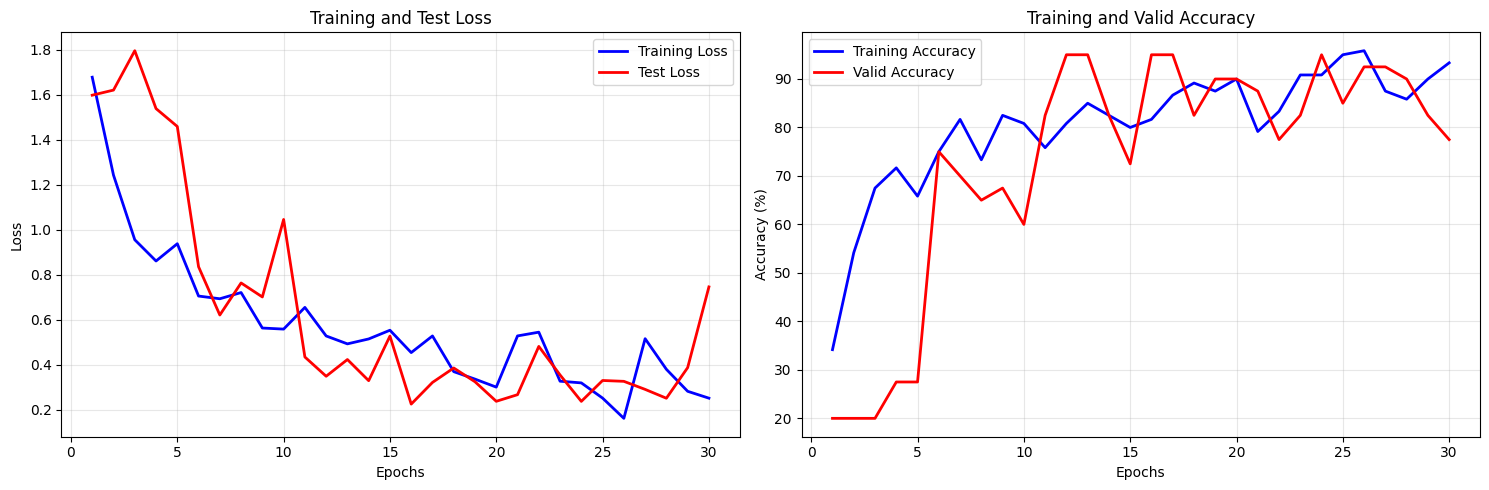

In [12]:
from torch.utils.data import DataLoader
from IPython.display import clear_output
from tqdm import tqdm_notebook


# Initialize datasets & dataloaders
train_data = SimpleAudioDataset(train_df, label_encoder, do_augmentation=True)
valid_data = SimpleAudioDataset(valid_df, label_encoder)
test_data = SimpleAudioDataset(test_df, is_test=True)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=16, shuffle=False)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

# Model, Loss, Optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
in_channels = [1, 32, 64, 128]
out_channels = [32, 64, 128, 258]
kernel_sizes = [13, 11, 7, 5]
strides = [2] * 4
paddings = [7, 5, 3, 2]
model = SoundClassificationModel(
    in_channels, out_channels, kernel_sizes, strides, paddings
    ).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

max_accuracy = -1
best_accuracy_epoch = -1
min_loss = float('inf')
best_loss_epoch = -1

n_epochs = 30
for epoch in range(n_epochs):
    print(f'epoch {epoch + 1}')
    # Train
    model.train()

    total_train_epoch_loss = 0
    total_val_epoch_loss = 0
    total_train_epoch_correct = 0
    total_val_epoch_correct = 0

    for signals, labels in tqdm_notebook(train_loader):

        # load data to device
        signals, labels = signals.to(device), labels.to(device)
        optimizer.zero_grad()
        # Forward pass
        predictions = model(signals)
        train_loss = criterion(predictions, labels)
        total_train_epoch_loss += train_loss.item()
        preds = torch.argmax(predictions, dim=1)

        total_train_epoch_correct += (preds == labels).sum().item()

        train_loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()
    with torch.no_grad():
        for signals, labels in tqdm_notebook(valid_loader):
            # load data to device
            signals, labels = signals.to(device), labels.to(device)

            # Forward pass
            predictions = model(signals)
            valid_loss = criterion(predictions, labels)
            total_val_epoch_loss += valid_loss.item()
            preds = torch.argmax(predictions, dim=1)

            total_val_epoch_correct += (preds == labels).sum().item()

    # Calculate average test loss and accuracy for this epoch
    epoch_train_loss = total_train_epoch_loss / len(train_loader)
    epoch_train_acc = total_train_epoch_correct / len(train_loader.dataset) * 100

    epoch_valid_loss = total_val_epoch_loss / len(valid_loader)
    epoch_valid_acc = total_val_epoch_correct / len(valid_loader.dataset) * 100

    if epoch_valid_acc > max_accuracy:
        max_accuracy = epoch_valid_acc
        best_accuracy_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_accuracy_model.pth')

    if epoch_valid_loss < min_loss:
        min_loss = epoch_valid_loss
        best_loss_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_loss_model.pth')

    # Store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_acc)

    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
    #clear_output(wait=True)

In [23]:
print("Train Accuracy = ", train_accuracies[best_accuracy_epoch - 1])
print("Valid Accuracy = ", max_accuracy)

Train Accuracy =  80.83333333333333
Valid Accuracy =  95.0


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

In [14]:
best_accuracy_model = SoundClassificationModel(
    in_channels, out_channels, kernel_sizes, strides, paddings
    ).to(device)
best_accuracy_model.load_state_dict(torch.load('best_accuracy_model.pth', weights_only=True))

<All keys matched successfully>

In [15]:
best_loss_model = SoundClassificationModel(
    in_channels, out_channels, kernel_sizes, strides, paddings
    ).to(device)
best_loss_model.load_state_dict(torch.load('best_loss_model.pth', weights_only=True))

<All keys matched successfully>

Using device: cuda
ESC-50 Audio Classification Demo!


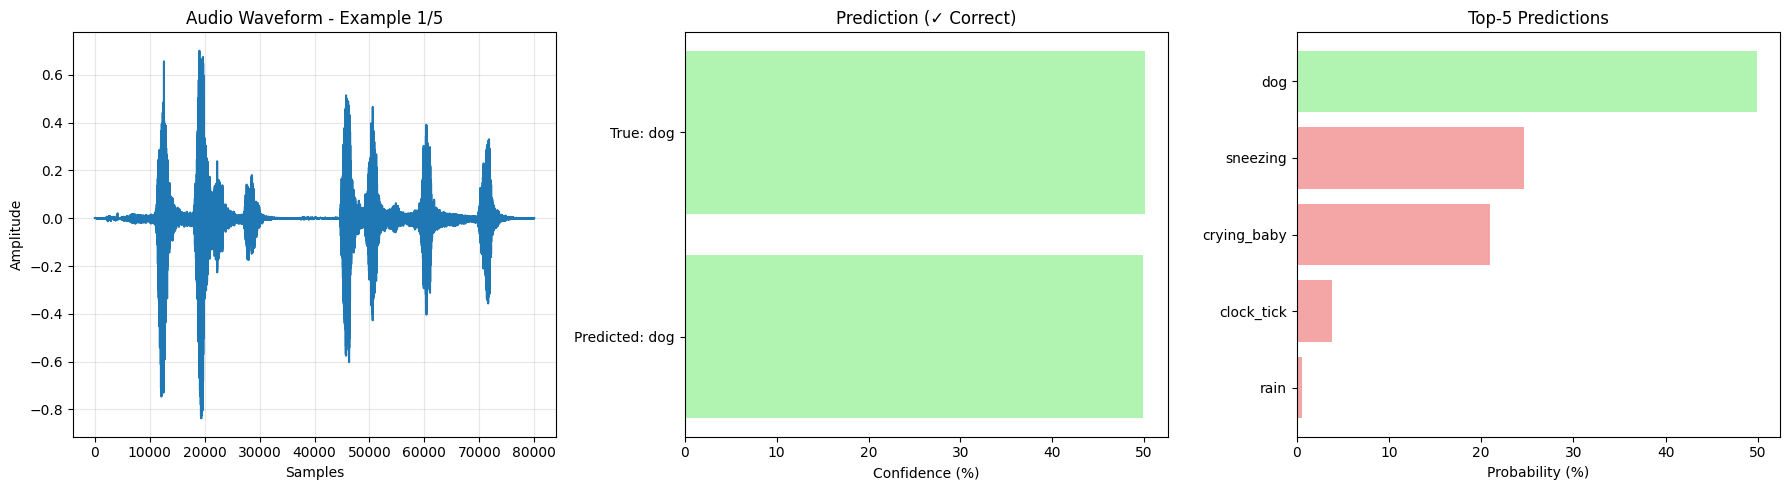

Playing: dog


Prediction: dog (49.89%)
True label: dog
Correct: True


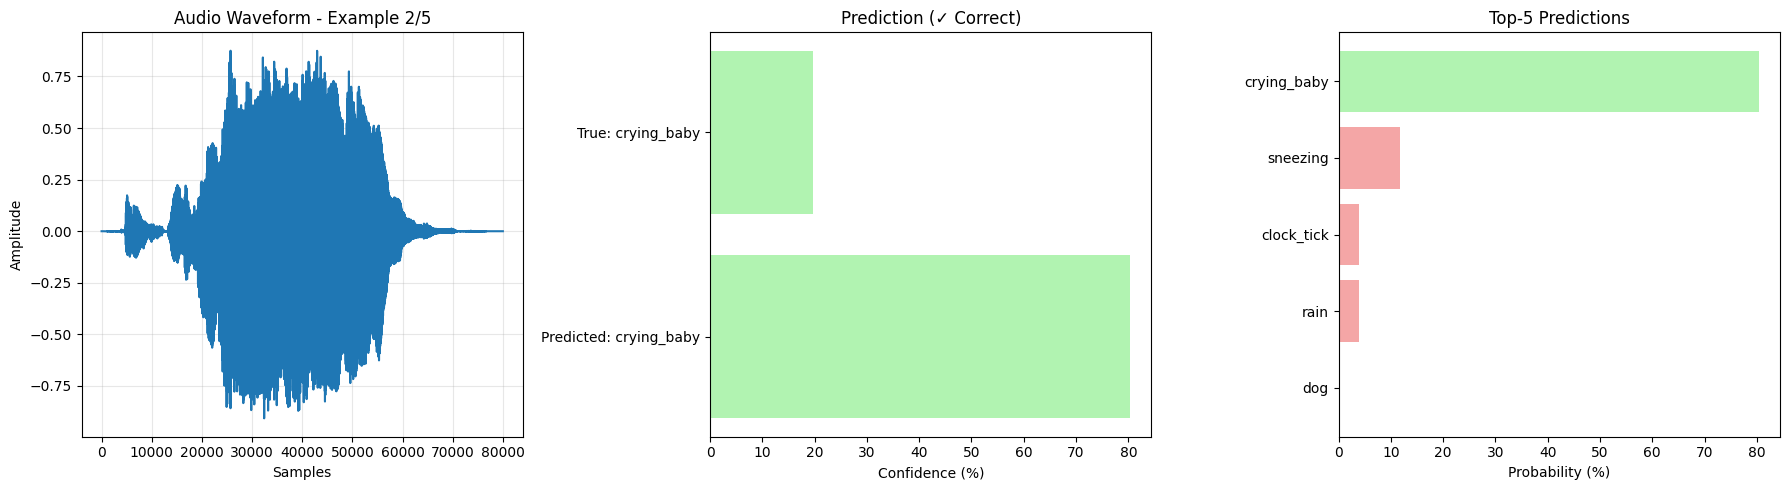

Playing: crying_baby


Prediction: crying_baby (80.40%)
True label: crying_baby
Correct: True


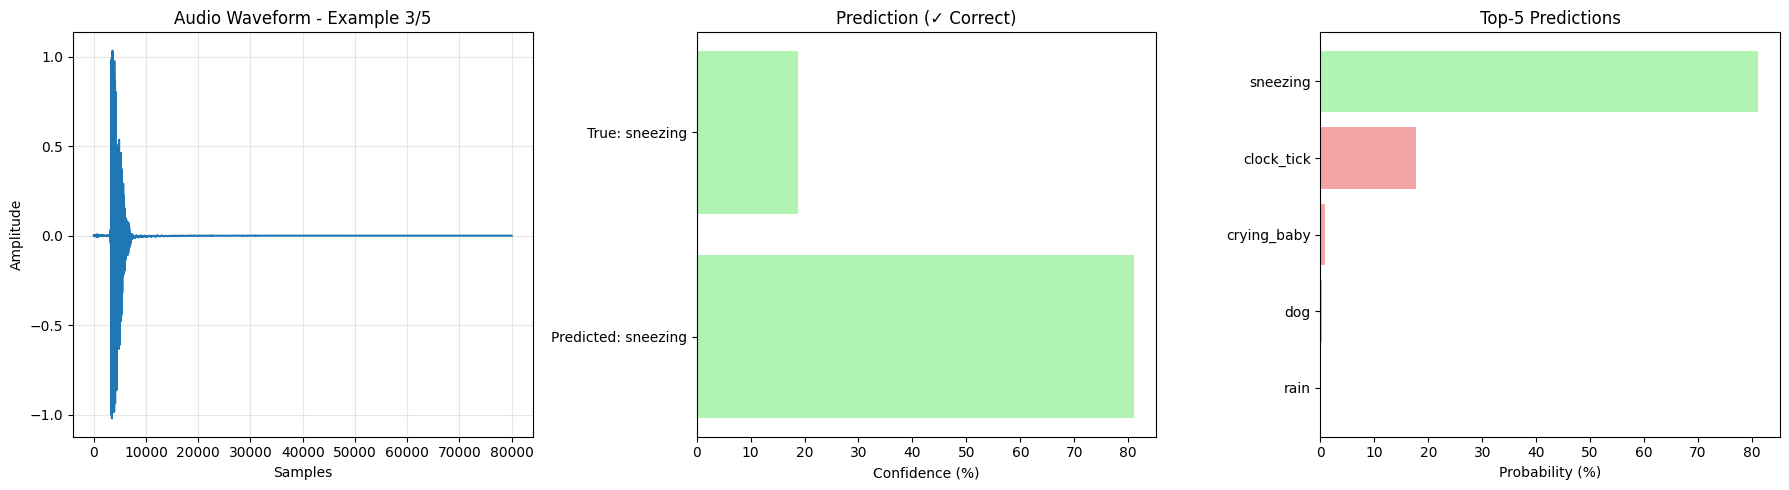

Playing: sneezing


Prediction: sneezing (81.14%)
True label: sneezing
Correct: True


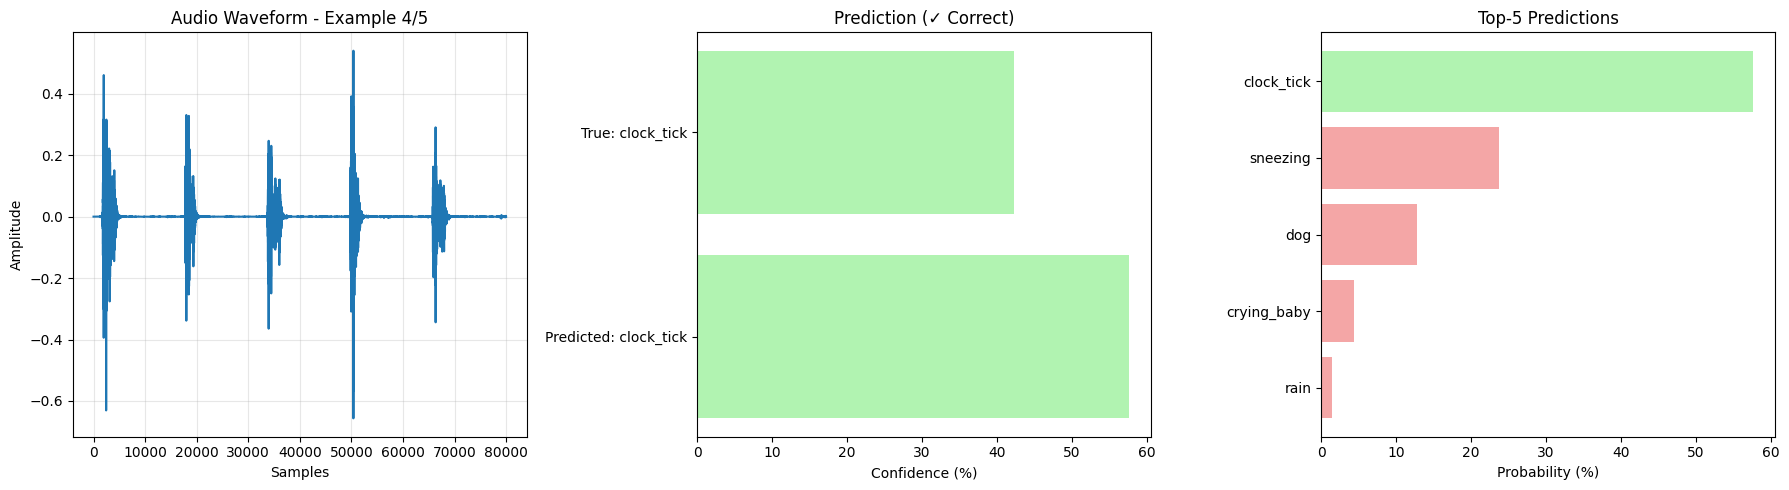

Playing: clock_tick


Prediction: clock_tick (57.67%)
True label: clock_tick
Correct: True


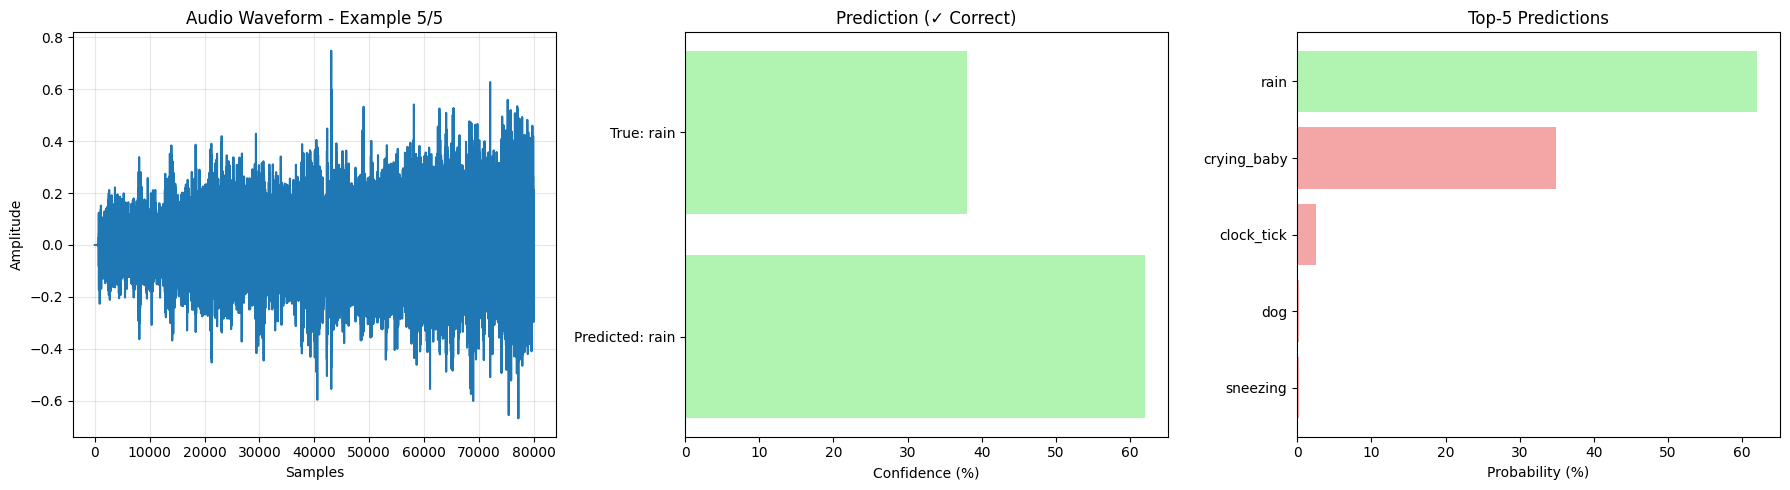

Playing: rain


Prediction: rain (62.01%)
True label: rain
Correct: True
ESC-50 Test Set Evaluation (Fold 5):
Correct: 38/40
Accuracy: 95.00%


In [16]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.label_encoder.classes_
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(best_accuracy_model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

ESC-50 Audio Classification Demo!


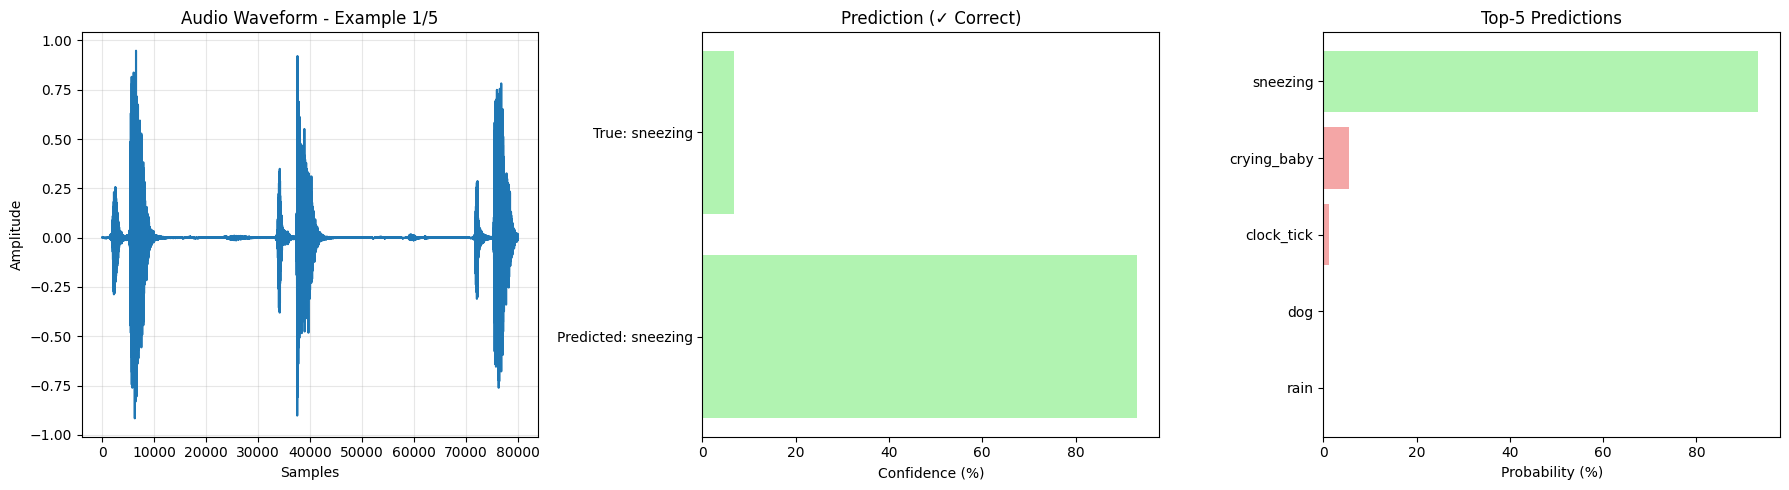

Playing: sneezing


Prediction: sneezing (93.28%)
True label: sneezing
Correct: True


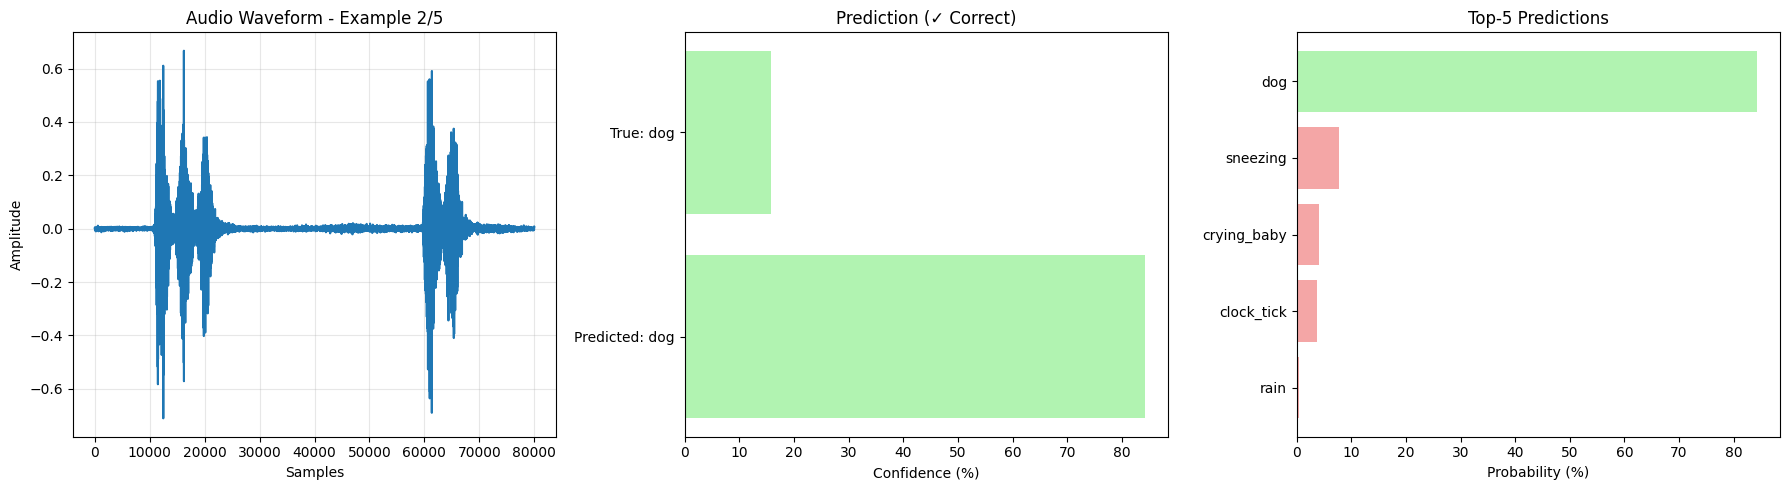

Playing: dog


Prediction: dog (84.26%)
True label: dog
Correct: True


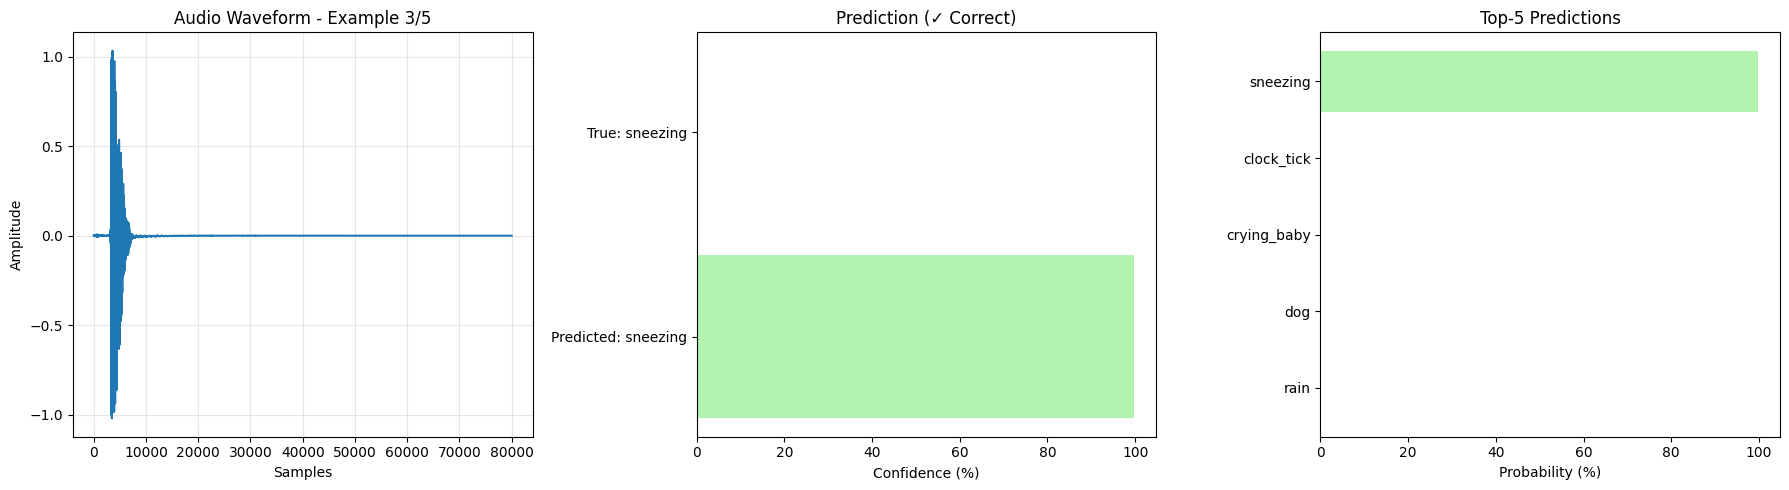

Playing: sneezing


Prediction: sneezing (99.82%)
True label: sneezing
Correct: True


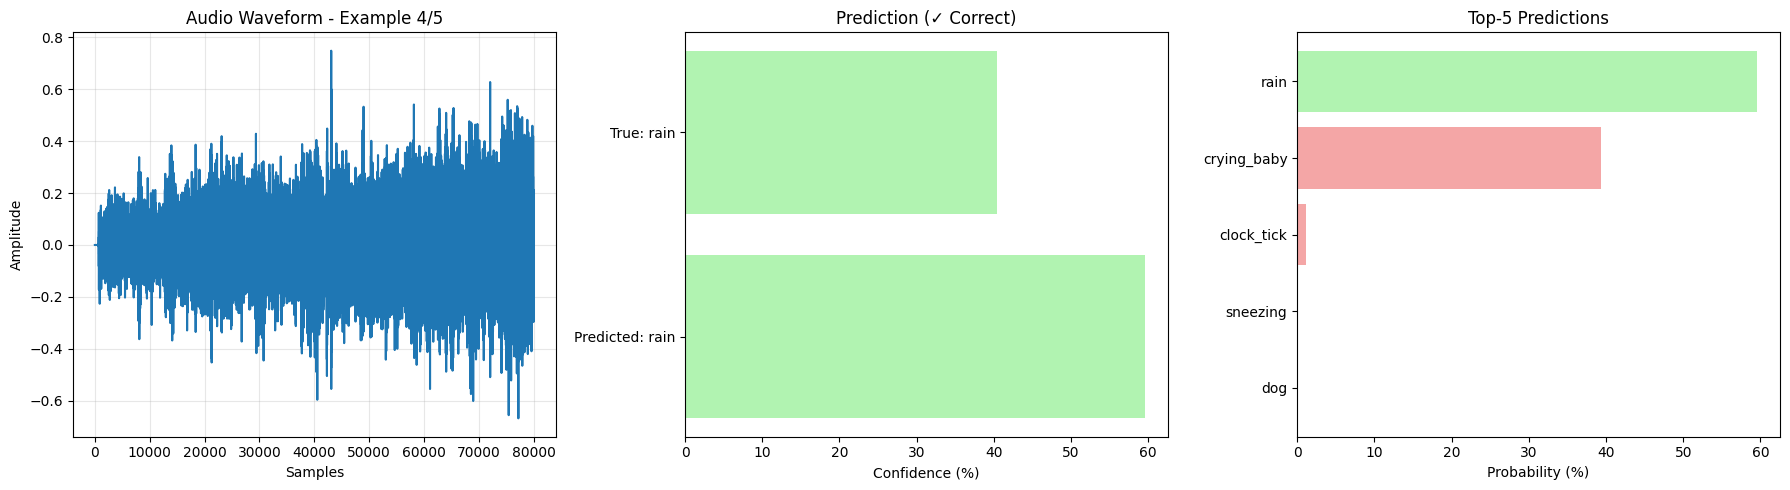

Playing: rain


Prediction: rain (59.56%)
True label: rain
Correct: True


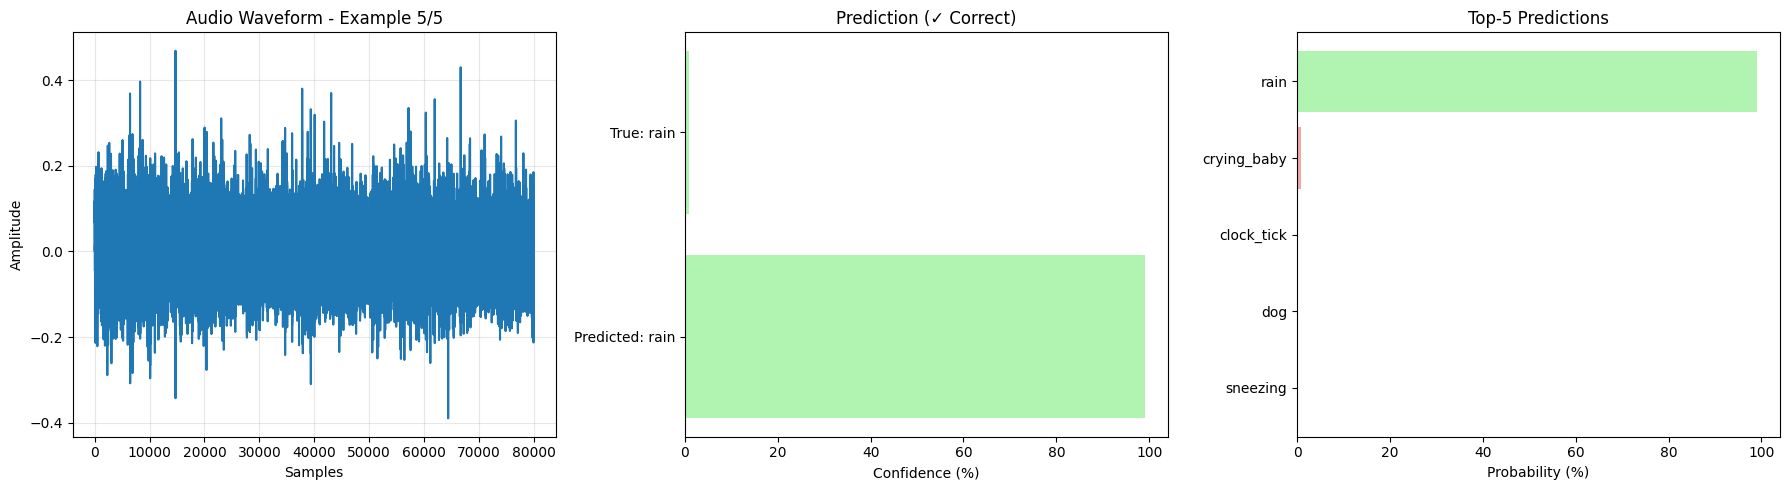

Playing: rain


Prediction: rain (99.06%)
True label: rain
Correct: True
ESC-50 Test Set Evaluation (Fold 5):
Correct: 38/40
Accuracy: 95.00%


In [17]:
# Create demo
demo = ESC50TestDemo(best_loss_model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [26]:
def predict(model, loader):
    model.eval()
    all_predictions = torch.tensor([]).to(device).int()
    print("Test mode...")
    for inputs in tqdm_notebook(loader):
        inputs = inputs.to(device)

        with torch.no_grad():
            outputs = model(inputs)

            predictions = outputs.argmax(-1).int()
            all_predictions = torch.cat((all_predictions, predictions), 0)
    return all_predictions.cpu()

In [19]:
y_test_accuracy_pred = label_encoder.inverse_transform(predict(best_accuracy_model, test_loader))

Test mode...


  0%|          | 0/3 [00:00<?, ?it/s]

In [20]:
submission = pd.read_csv("/content/test.csv")
submission['category'] = y_test_accuracy_pred
submission.to_csv("/content/submission_accuracy.csv", index=False)

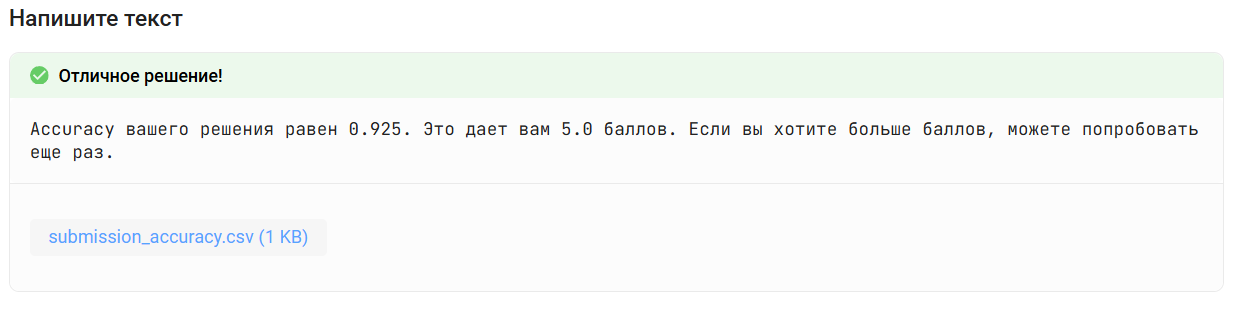

In [21]:
y_test_loss_pred = label_encoder.inverse_transform(predict(best_loss_model, test_loader))

Test mode...


  0%|          | 0/3 [00:00<?, ?it/s]

In [22]:
submission = pd.read_csv("/content/test.csv")
submission['category'] = y_test_loss_pred
submission.to_csv("/content/submission_loss.csv", index=False)

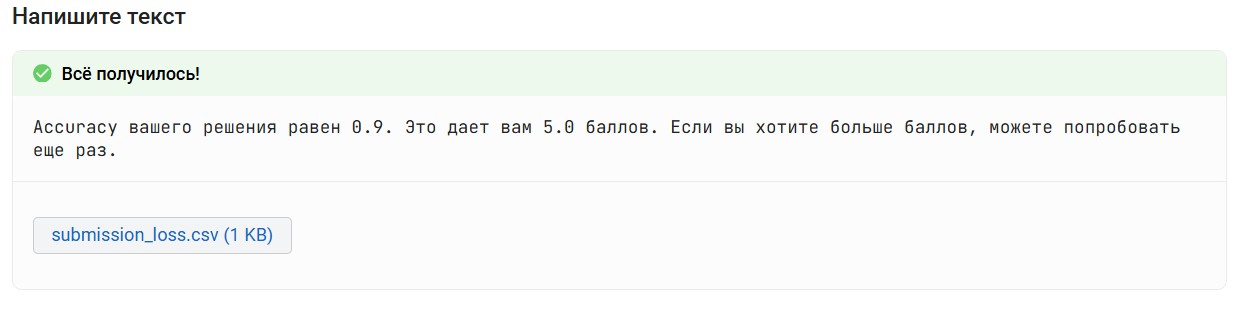

### **Report**

Опишите ваш путь экспериментов и что вы сделали, чтобы получить наилучшую модель.

- Для обработки сырых wav были использованы аугментации: Gain (изменение громкости), PolarityInversion (Инверсия полярности), PitchShift(Изменение высоты тона). В ходе экспериментов было выяснено, что лучше всего использовать три аугментации вместе
- Так как задача - обработать ряд, то была выбрана 1D-CNN модель
- Feature extractor состоит из 4 блоков `Conv -> BN -> RELU -> Pool`. В каждом блоке можно настроить параметры: размеры входного слоя, выходного слоя, размер ядра свертки, padding и stride. Подбор параметров был примерно случайным, но обусловлен тем, что размер ядра и padding должен уменьшаться, чтобы улавливать более высокоуровневые признаки
- Классификатором является простая полносвязная сеть из 2 слоёв
- Между feature extractor и классификатором есть слой - конкатенация AdaptiveMaxPool1d и AdaptiveAvgPool1d. Выбор был обусловлен тем, что после прохождения feature extractor размер выходного слоя при моих подобранных параметрах достаточно большой, а примеров в обучающей выборке мало, что может привести к переобучению. Поэтому были использованы адаптивные пуллинги, которые для каждой карты находят среднее/максимум, а затем они конкатенируются. Были экперименты по использованию каждого пуллинга отдельно, но результаты были хуже, чем при совместном использовании